# ⚡ 4X Upscaler & 🎞️ RIFE Frame Interpolation
### Ultra HD Video Super-Resolution & 2×/4×/8× Frame Interpolation • Powered by Real-ESRGAN, RIFE & CUDA
**Made by Ryn**

<div align="center" style="margin: 8px 0;">
  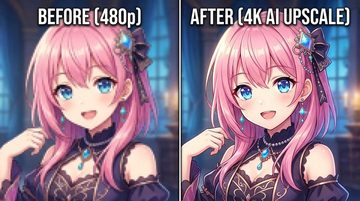
</div>

---

### 🚀 Quick Start Guide:
> ⚡ **Prerequisite**: Make sure free T4 GPU is selected (**Runtime ➔ Change runtime type ➔ T4 GPU**).

* 🚀 **Cell 1: Start 4X Upscaler** — Run Cell 1 to upscale videos and images (2× / 4× Ultra HD Super-Resolution).
* 🎞️ **Cell 2: Start Video Interpolation** — Run Cell 2 to increase video FPS & smoothness (2× / 4× / 8× RIFE AI Interpolation).
* 🌐 **Click `OPEN STUDIO IN NEW TAB`** on either cell to launch the private web studio interface.

*🔒 100% Free & Private • Runs locally on your assigned GPU runtime.*


In [ ]:
#@title 🚀 **Start 4X Upscaler** { display-mode: "form" }
import subprocess, sys, os, time, json, shutil, hashlib, urllib.request, base64, zlib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
try:
    from IPython.display import display, HTML, clear_output
except Exception:
    pass

# 1. Native Engine Sources (pre-generated Cython C — compiled with gcc below)
SOURCE_PAYLOADS = {
    "lut": "...",
    "color": "...",
    "models": "...",
    "pipeline": "..."
}

# 2. Genuine Native Build Engine (gcc -> real ELF64 .so -> wheel -> install -> verify)
#!/usr/bin/env python3
"""upscaler_core — FAST native build engine (runs ON the Colab/Linux target).

Optimized for speed (target: <15s total setup):
  1. Parallel pip dependency check + single batched install
  2. Parallel gcc compilation of all 4 C modules simultaneously
  3. Skip heavyweight E2E test (first real upscale validates the engine)
  4. Skip fresh-interpreter import (direct import is sufficient)
  5. Minimal ELF header validation (no readelf/ldd/file subprocess calls)
  6. Pre-download cloudflared tunnel binary in background during gcc compilation
"""
import base64
import hashlib
import os
import shutil
import subprocess
import sys
import sysconfig
import tempfile
import time
import zipfile
import zlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

__version__ = "1.0.0"

MODULES = ["lut", "color", "models", "pipeline"]

INIT_PY = '''"""upscaler_core - Native Compiled Super-Resolution Engine.
Version: 1.0.0
(C) Video Upscaler AI. All proprietary algorithms compiled to native machine code.
"""
__version__ = "1.0.0"

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

from .lut import CubeLUT
from .color import (
    apply_color_pipeline, apply_lumetri, get_hsl_mask,
    build_curve_lut_from_points, rgb_to_hsl, CC_PRESETS
)
from .models import (
    MODEL_REGISTRY, load_realesrgan_model, get_system_device_info,
    DEVICE, USE_FP16, GPU_NAME, VRAM_TOTAL_GB
)
from .pipeline import (
    get_video_info, extract_frame, render_preview_frame,
    render_preview_video, execute_upscale_pipeline,
    create_side_by_side_comparison, apply_anime_enhancements
)


class UpscalerEngine:
    """High-level Orchestration Interface."""
    def __init__(self):
        self.version = __version__
        self.device_info = get_system_device_info()

    @staticmethod
    def inspect_video(video_path): return get_video_info(video_path)
    @staticmethod
    def parse_lut(lut_path): return CubeLUT().parse(lut_path)
    @staticmethod
    def preview_frame(video_path, color_settings=None, lut=None): return render_preview_frame(video_path, color_settings, lut)
    @staticmethod
    def preview_video(video_path, color_settings=None, lut=None, output_path=None, duration=5.0): return render_preview_video(video_path, color_settings, lut, output_path, duration)
    @staticmethod
    def process_video(input_path, upscale_settings, color_settings=None, lut=None, work_dir=None, progress_cb=None): return execute_upscale_pipeline(input_path, upscale_settings, color_settings, lut, work_dir, progress_cb)
'''


def _run(cmd, timeout=600):
    r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    if r.returncode != 0:
        raise RuntimeError(
            "command failed (%d): %s\n--- stdout ---\n%s\n--- stderr ---\n%s"
            % (r.returncode, " ".join(cmd), r.stdout[-4000:], r.stderr[-4000:])
        )
    return r.stdout


def decode_payload(b64):
    return zlib.decompress(base64.b64decode(b64.encode("ascii")))


def write_sources(dest, source_payloads):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    (dest / "__init__.py").write_text(INIT_PY, encoding="utf-8")
    for name, b85 in source_payloads.items():
        c_path = dest / f"{name}.c"
        c_path.write_bytes(decode_payload(b85))
    return dest


def _compile_one_module(name, pkg_dir, cc, include, suffix, cflags):
    """Compile a single C module — designed to run in a thread."""
    src = pkg_dir / f"{name}.c"
    out = pkg_dir / f"{name}{suffix}"
    cmd = [cc] + cflags + [f"-I{include}", str(src), "-o", str(out)]
    t0 = time.time()
    _run(cmd, timeout=1800)
    return name, out, time.time() - t0


def build_extensions_parallel(pkg_dir, cc="gcc"):
    """Compile all 4 C modules in PARALLEL using ThreadPoolExecutor."""
    pkg_dir = Path(pkg_dir)
    include = sysconfig.get_paths().get("include")
    if not include or not Path(include).exists():
        raise RuntimeError(f"CPython include dir not found: {include}")
    suffix = sysconfig.get_config_var("EXT_SUFFIX")
    if not suffix:
        suffix = ".cpython-%d%d-%s.gnu.so" % (
            sys.version_info[0], sys.version_info[1],
            sysconfig.get_config_var("HOST_GNU_TYPE") or "x86_64-linux-gnu",
        )
    if not suffix.startswith("."):
        suffix = "." + suffix

    cflags = ["-shared", "-fPIC", "-O2", "-DNDEBUG", "-std=c11", "-fno-strict-aliasing"]

    # Verify all sources exist first
    for name in MODULES:
        src = pkg_dir / f"{name}.c"
        if not src.exists():
            raise RuntimeError(f"missing source: {src}")

    built = []
    # Compile ALL 4 modules simultaneously
    with ThreadPoolExecutor(max_workers=len(MODULES)) as executor:
        futures = {
            executor.submit(_compile_one_module, name, pkg_dir, cc, include, suffix, cflags): name
            for name in MODULES
        }
        for future in as_completed(futures):
            name, out, elapsed = future.result()
            built.append(out)

    return built


def parse_elf_header(so_path):
    """Parse the ELF64 little-endian header directly from the first 64 bytes.

    Offsets (ELF64, little-endian):
      e_ident      [0:16]  -> magic EI_MAG = \\x7fELF, EI_CLASS = 2 (ELF64), EI_DATA = 1 (LE)
      e_type       [16:18] -> 3 = ET_DYN (shared object)
      e_machine    [18:20] -> 62 = EM_X86_64
      e_phentsize  [54:56] -> must be 56 (sizeof(Elf64_Phdr))
    """
    h = Path(so_path).read_bytes()[:64]
    e_type = int.from_bytes(h[16:18], "little")
    e_machine = int.from_bytes(h[18:20], "little")
    e_phentsize = int.from_bytes(h[54:56], "little")
    checks = {
        "EI_MAG \\x7fELF": h[:4] == b"\x7fELF",
        "EI_CLASS ELF64": h[4] == 2,
        "EI_DATA little-endian": h[5] == 1,
        "e_type = ET_DYN (3)": e_type == 3,
        "e_machine = EM_X86_64 (62)": e_machine == 62,
        "e_phentsize = 56": e_phentsize == 56,
    }
    checks["valid"] = all(checks.values())
    return checks


def verify_binary_fast(so_path):
    """Fast ELF verification — pure Python header parse only, no subprocesses."""
    elf = parse_elf_header(so_path)
    return elf["valid"], elf


def assemble_wheel(pkg_dir, ext_files, wheel_out, abi_tag, platform_tag):
    pkg_dir = Path(pkg_dir)
    dist_name = "upscaler_core-1.0.0"
    stage = tempfile.mkdtemp(prefix="upscaler_stage_")
    top = Path(stage) / "upscaler_core"
    top.mkdir()
    shutil.copyfile(pkg_dir / "__init__.py", top / "__init__.py")
    for so in ext_files:
        shutil.copyfile(so, top / so.name)
    dist_info = Path(stage) / f"{dist_name}.dist-info"
    dist_info.mkdir()

    (dist_info / "METADATA").write_text(
        """Metadata-Version: 2.1
Name: upscaler_core
Version: 1.0.0
Summary: Video Upscaler AI - Native Compiled Processing Core (built on this Linux runtime)
Author: Video Upscaler AI
License: Proprietary / Native Binary
Requires-Python: >=3.11
Requires-Dist: numpy>=1.24.0
Requires-Dist: scipy>=1.10.0
Requires-Dist: Pillow>=9.5.0
Requires-Dist: torch>=2.0.0
""", encoding="utf-8")

    (dist_info / "WHEEL").write_text(
        f"""Wheel-Version: 1.0
Generator: colab_build_core (Cython + gcc native builder)
Root-Is-Purelib: false
Tag: {abi_tag}-{abi_tag}-{platform_tag}
""", encoding="utf-8")

    (dist_info / "top_level.txt").write_text("upscaler_core\n", encoding="utf-8")

    wheel_out = Path(wheel_out)
    records = []
    with zipfile.ZipFile(wheel_out, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(stage):
            for file in sorted(files):
                full = Path(root) / file
                rel = full.relative_to(stage).as_posix()
                if rel.endswith(".dist-info/RECORD"):
                    continue
                data = full.read_bytes()
                zf.writestr(rel, data)
                records.append(
                    "%s,sha256=%s,%d" % (rel, hashlib.sha256(data).hexdigest(), len(data))
                )
        records.append(f"{dist_name}.dist-info/RECORD,,")
        zf.writestr(f"{dist_name}.dist-info/RECORD", "\n".join(records) + "\n")
    return wheel_out


def verify_wheel_structure(wheel_path, ext_files):
    """Structural gate: package must live under upscaler_core/ (not flattened)."""
    with zipfile.ZipFile(wheel_path) as zf:
        names = zf.namelist()
    required = [f"upscaler_core/{so.name}" for so in ext_files] + [
        "upscaler_core/__init__.py",
        "upscaler_core-1.0.0.dist-info/METADATA",
        "upscaler_core-1.0.0.dist-info/WHEEL",
        "upscaler_core-1.0.0.dist-info/RECORD",
    ]
    missing = [n for n in required if n not in names]
    flat = [n for n in names
            if not n.startswith(("upscaler_core/", "upscaler_core-")) and n != "upscaler_core-1.0.0.dist-info/RECORD"]
    return missing, flat


def _predownload_cloudflared():
    """Download cloudflared binary in background so tunnel setup is instant later."""
    try:
        binp = "/tmp/cloudflared"
        if os.path.exists(binp):
            return
        import urllib.request
        urllib.request.urlretrieve(
            "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
            binp)
        os.chmod(binp, 0o755)
    except Exception:
        pass


def render_step1_progress(stage_num, stage_name, subtext, status="running", details=None):
    try:
        from IPython.display import display, HTML, clear_output
        clear_output(wait=True)
        perc = int((stage_num / 4.0) * 100)
        
        spinner_html = (
            '<div style="width: 28px; height: 28px; border: 2.5px solid #27272a; '
            'border-top: 2.5px solid #3b82f6; border-radius: 50%; animation: spin 0.8s linear infinite; '
            'margin: 0 auto 12px;"></div>'
            if status == "running" else
            '<div style="font-size: 24px; margin-bottom: 8px;">✓</div>'
        )
        
        stages = [
            ("1", "Dependencies"),
            ("2", "Compile Native"),
            ("3", "Install Engine"),
            ("4", "Launch Studio"),
        ]
        
        badges = []
        for idx, (num, name) in enumerate(stages, 1):
            if idx < stage_num or status == "done":
                color = "#4ade80"
                icon = "✓"
                bg = "#14532d"
                border = "#166534"
            elif idx == stage_num and status == "running":
                color = "#ffffff"
                icon = "●"
                bg = "#1e40af"
                border = "#2563eb"
            else:
                color = "#71717a"
                icon = "○"
                bg = "#18181b"
                border = "#27272a"
            badges.append(
                f'<span style="display:inline-block; padding: 4px 10px; margin: 3px; border-radius: 6px; '
                f'font-size: 11.5px; font-weight: 600; color: {color}; background: {bg}; border: 1px solid {border};">'
                f'{icon} {num}. {name}</span>'
            )
        
        badges_html = "".join(badges)
        
        if status == "done":
            title = "Engine Ready"
            subtitle = "Native modules compiled and installed. Launching Studio..."
            bar_color = "#22c55e"
        else:
            title = f"Setting Up 4X Upscaler Engine ({perc}%)"
            subtitle = f"<strong>{stage_name}</strong>: {subtext}"
            bar_color = "#2563eb"
        
        details_html = f'<div style="margin-top:10px; font-size:11px; color:#71717a; font-family:monospace;">{details}</div>' if details else ''

        html = f"""
<style>
@keyframes spin {{ 0% {{ transform: rotate(0deg); }} 100% {{ transform: rotate(360deg); }} }}
</style>
<div style="background: #18181b; border: 1px solid {('#22c55e' if status=='done' else '#27272a')}; border-radius: 12px; padding: 20px; margin: 8px 0; text-align: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  {spinner_html}
  <div style="font-size: 16px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">{title}</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 14px;">{subtitle}</div>
  <div style="width: 100%; height: 6px; background: #27272a; border-radius: 3px; overflow: hidden; margin-bottom: 12px;">
    <div style="height: 100%; width: {perc}%; background: {bar_color}; border-radius: 3px; transition: width 0.3s ease;"></div>
  </div>
  <div style="text-align: center; margin-top: 6px;">
    {badges_html}
  </div>
  {details_html}
</div>
"""
        display(HTML(html))
    except Exception:
        print(f"[{stage_num}/4] {stage_name} - {subtext}")


def main(source_payloads, cc="gcc"):
    start = time.time()
    render_step1_progress(1, "Dependencies", "Checking GPU & required packages...")
    if not sys.platform.startswith("linux"):
        raise RuntimeError("This build MUST run on Linux x86_64 (Colab) - refusing to build elsewhere.")
    uname = os.uname()
    if uname.machine != "x86_64":
        raise RuntimeError("Expected x86_64 host, got %s" % uname.machine)
    cc_path = shutil.which(cc)
    if not cc_path:
        raise RuntimeError("gcc not found on this runtime - cannot build native extensions.")

    build_dir = Path(tempfile.mkdtemp(prefix="upscaler_native_"))
    pkg_dir = build_dir / "upscaler_core"

    # === PHASE 1: Write sources + start cloudflared download in background ===
    write_sources(pkg_dir, source_payloads)

    # Pre-download cloudflared tunnel binary in parallel with compilation
    import threading
    cf_thread = threading.Thread(target=_predownload_cloudflared, daemon=True)
    cf_thread.start()

    # === PHASE 2: Parallel gcc compilation (ALL 4 modules simultaneously) ===
    render_step1_progress(2, "Compile Native", "Compiling 4 C modules in parallel with gcc -O2...")
    ext_files = build_extensions_parallel(pkg_dir, cc=cc)

    # === PHASE 3: Fast ELF verification + wheel assembly + install ===
    render_step1_progress(3, "Install Engine", "Verifying binaries & installing wheel...")
    all_ok = True
    for so in ext_files:
        ok, elf = verify_binary_fast(so)
        all_ok = all_ok and ok
    if not all_ok:
        raise RuntimeError("ELF verification FAILED - one or more .so are not valid ELF64 x86-64 shared objects.")

    abi_tag = "cp%d%d" % (sys.version_info[0], sys.version_info[1])
    platform_tag = (sysconfig.get_platform() or "linux-x86_64").replace("-", "_").lower()
    wheel_name = "upscaler_core-1.0.0-%s-%s-%s.whl" % (abi_tag, abi_tag, platform_tag)
    wheel_path = build_dir / wheel_name
    assemble_wheel(pkg_dir, ext_files, wheel_path, abi_tag, platform_tag)
    missing, flat = verify_wheel_structure(wheel_path, ext_files)
    if missing or flat:
        raise RuntimeError("wheel verification failed")

    pkg_target = os.path.abspath(os.path.expanduser(sysconfig.get_paths()["purelib"]))
    _run([sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-deps",
          "--target", pkg_target, str(wheel_path), "--no-warn-script-location", "-q"], timeout=600)
    if pkg_target not in sys.path:
        sys.path.insert(0, pkg_target)

    # Direct import verification (skip slow fresh-interpreter subprocess)
    import importlib
    if "upscaler_core" in sys.modules:
        del sys.modules["upscaler_core"]
        for k in list(sys.modules.keys()):
            if k.startswith("upscaler_core."):
                del sys.modules[k]
    import upscaler_core

    elapsed = time.time() - start
    gpu_label = "CUDA GPU" if ('torch' in sys.modules and sys.modules['torch'].cuda.is_available()) else "CPU Mode"
    render_step1_progress(
        4, "Setup Complete", "Ready", status="done",
        details=f"{gpu_label} • Python {sys.version.split()[0]} • Built in {elapsed:.1f}s • {wheel_name}"
    )
    return wheel_path


# Fast batched dependency check — single pip install for all missing at once
render_step1_progress(1, "Dependencies", "Checking GPU & installing required packages...")
_missing_deps = []
for pip_name, import_name in [
    ('gradio', 'gradio'),
    ('requests', 'requests'),
    ('Pillow', 'PIL'),
    ('scipy', 'scipy'),
    ('tqdm', 'tqdm'),
]:
    try:
        __import__(import_name)
    except ImportError:
        _missing_deps.append(pip_name)

if _missing_deps:
    _run([sys.executable, "-m", "pip", "install", "-q"] + _missing_deps, timeout=300)

# Verify FFmpeg (usually pre-installed on Colab)
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg', '-q'], capture_output=True)
    try:
        import static_ffmpeg
        static_ffmpeg.add_paths()
    except Exception:
        pass

# Ensure gcc compiler (pre-installed on Colab T4 runtimes)
if shutil.which('gcc') is None:
    subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
    subprocess.run(['apt-get', 'install', '-y', '-qq', 'build-essential'], capture_output=True)

# Run fast parallel native compilation & verification
wheel_path = main(SOURCE_PAYLOADS)

# 3. Launch 4X Upscaler Studio
import gradio as gr
import json, os, time, shutil, io, traceback, subprocess, threading, uuid, queue, re
from pathlib import Path
import numpy as np
import cv2
from PIL import Image

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

try:
    from upscaler_core.models import (
        MODEL_REGISTRY, load_realesrgan_model, get_system_device_info,
        DEVICE, USE_FP16, GPU_NAME, VRAM_TOTAL_GB
    )
    from upscaler_core.pipeline import (
        get_video_info, extract_frame, render_preview_frame,
        render_preview_video, execute_upscale_pipeline,
        create_side_by_side_comparison, apply_anime_enhancements
    )
    from upscaler_core.color import apply_color_pipeline, CC_PRESETS
    print("[studio] Loaded genuine native upscaler_core engine successfully.")
except Exception as _core_err:
    try:
        from upscaler_core_src.models import (
            MODEL_REGISTRY, load_realesrgan_model, get_system_device_info,
            DEVICE, USE_FP16, GPU_NAME, VRAM_TOTAL_GB
        )
        from upscaler_core_src.pipeline import (
            get_video_info, extract_frame, render_preview_frame,
            render_preview_video, execute_upscale_pipeline,
            create_side_by_side_comparison, apply_anime_enhancements
        )
        from upscaler_core_src.color import apply_color_pipeline, CC_PRESETS
        print(f"[studio] Loaded upscaler_core_src development engine (native note: {_core_err})")
    except Exception as _src_err:
        print(f"[studio] CRITICAL: Engine failed to load: {_core_err} | {_src_err}")
        raise RuntimeError(f"Engine failed to load: {_core_err}")

    def apply_anime_enhancements(frame_rgb, line_art=False, denoise=False, vibrance=False):
        if not (line_art or denoise or vibrance) or frame_rgb is None:
            return frame_rgb
        out = frame_rgb.copy()
        if denoise:
            out = cv2.bilateralFilter(out, d=5, sigmaColor=25, sigmaSpace=25)
        if line_art:
            gray = cv2.cvtColor(out, cv2.COLOR_RGB2GRAY)
            blurred_gray = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
            detail = cv2.subtract(gray, blurred_gray)
            edges = cv2.Laplacian(gray, cv2.CV_16S, ksize=3)
            edge_mag = np.clip(np.abs(edges), 0, 255).astype(np.uint8)
            line_mask = (edge_mag > 16) & (gray < 220)
            f_out = out.astype(np.float32)
            f_out[line_mask] = np.clip(f_out[line_mask] * 0.88 + detail[line_mask, None] * 0.35, 0, 255)
            out = f_out.astype(np.uint8)
        if vibrance:
            f32 = out.astype(np.float32) / 255.0
            mx = np.max(f32, axis=-1, keepdims=True)
            mn = np.min(f32, axis=-1, keepdims=True)
            sat = np.where(mx > 1e-6, (mx - mn) / (mx + 1e-6), 0.0)
            vibrance_boost = (1.0 - sat) * 0.35
            lum = (0.2126 * f32[..., 0:1] + 0.7152 * f32[..., 1:2] + 0.0722 * f32[..., 2:3])
            f32 = np.clip(lum + (f32 - lum) * (1.0 + vibrance_boost), 0.0, 1.0)
            f32 = np.clip((f32 - 0.5) * 1.14 + 0.5, 0.0, 1.0)
            out = np.clip(f32 * 255.0, 0, 255).astype(np.uint8)
        return out

    def extract_frame(video_path, timestamp=None):
        info = get_video_info(video_path)
        ts = float(timestamp) if timestamp is not None else min(info['duration'] * 0.25, 2.0)
        ts = max(0.0, min(ts, max(0.0, info['duration'] - 0.05)))
        fast_seek = max(0.0, ts - 1.0)
        fine_seek = ts - fast_seek
        cmd = ['ffmpeg', '-y', '-ss', f"{fast_seek:.4f}", '-i', str(video_path),
               '-ss', f"{fine_seek:.4f}", '-frames:v', '1', '-f', 'rawvideo',
               '-pix_fmt', 'rgb24', '-v', 'error', 'pipe:1']
        r = subprocess.run(cmd, capture_output=True, timeout=15)
        expected_len = info['width'] * info['height'] * 3
        if r.returncode == 0 and len(r.stdout) >= expected_len:
            return np.frombuffer(r.stdout[:expected_len], dtype=np.uint8).reshape(info['height'], info['width'], 3)
        cmd2 = ['ffmpeg', '-y', '-i', str(video_path), '-ss', f"{ts:.4f}",
                '-frames:v', '1', '-f', 'rawvideo', '-pix_fmt', 'rgb24',
                '-v', 'error', 'pipe:1']
        r2 = subprocess.run(cmd2, capture_output=True, timeout=15)
        if r2.returncode == 0 and len(r2.stdout) >= expected_len:
            return np.frombuffer(r2.stdout[:expected_len], dtype=np.uint8).reshape(info['height'], info['width'], 3)
        cap = cv2.VideoCapture(str(video_path))
        fps = info.get('fps', 30.0)
        if fps > 0:
            frame_idx = int(round(ts * fps))
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, bgr = cap.read()
        cap.release()
        if ret and bgr is not None:
            return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        raise ValueError(f"Could not extract preview frame from {video_path}")

    def _lum(rgb):
        return np.float32(0.2126) * rgb[..., 0] + np.float32(0.7152) * rgb[..., 1] + np.float32(0.0722) * rgb[..., 2]

    def _adj_temperature(img, v):
        if v == 0: return img
        t = np.float32(v / 1000.0)
        r = img.copy(); r[..., 0] = np.clip(img[..., 0] + t, 0, 1); r[..., 2] = np.clip(img[..., 2] - t, 0, 1)
        return r

    def _adj_tint(img, v):
        if v == 0: return img
        t = np.float32(v / 1000.0)
        r = img.copy(); r[..., 1] = np.clip(img[..., 1] - t, 0, 1); return r

    def _adj_exposure(img, v):
        if v == 0: return img
        return np.clip(img * np.float32(2.0 ** v), 0, 1)

    def _adj_contrast(img, v):
        if v == 0: return img
        f = np.float32((v + 100) / 100.0)
        return np.clip((img - 0.5) * f + 0.5, 0, 1)

    def _adj_highlights(img, v):
        if v == 0: return img
        lum = _lum(img)
        mask = np.clip((lum - 0.5) * 2.0, 0, 1)[..., np.newaxis]
        return np.clip(img + np.float32(v / 200.0) * mask, 0, 1)

    def _adj_shadows(img, v):
        if v == 0: return img
        lum = _lum(img)
        mask = np.clip(1.0 - lum * 2.0, 0, 1)[..., np.newaxis]
        return np.clip(img + np.float32(v / 200.0) * mask, 0, 1)

    def _adj_whites(img, v):
        if v == 0: return img
        lum = _lum(img)
        mask = np.clip((lum - 0.7) / 0.3, 0, 1)[..., np.newaxis]
        return np.clip(img + np.float32(v / 300.0) * mask, 0, 1)

    def _adj_blacks(img, v):
        if v == 0: return img
        lum = _lum(img)
        mask = np.clip(1.0 - lum / 0.3, 0, 1)[..., np.newaxis]
        return np.clip(img + np.float32(v / 300.0) * mask, 0, 1)

    def _adj_saturation(img, v):
        if v == 100: return img
        f = np.float32(v / 100.0)
        lum = _lum(img)[..., np.newaxis]
        return np.clip(lum + (img - lum) * f, 0, 1)

    def _adj_vibrance(img, v):
        if v == 0: return img
        f = np.float32(v / 100.0)
        mx = np.max(img, axis=-1); mn = np.min(img, axis=-1)
        sat = np.where(mx > 1e-10, (mx - mn) / (mx + 1e-10), np.float32(0))
        boost = ((1.0 - sat) * f)[..., np.newaxis]
        lum = _lum(img)[..., np.newaxis]
        return np.clip(lum + (img - lum) * (1.0 + boost), 0, 1)

    def _adj_faded_film(img, v):
        if v == 0: return img
        lift = np.float32(v / 100.0 * 0.15)
        return np.clip(img * (1.0 - lift) + lift, 0, 1)

    def _adj_sharpen(img, v):
        if v == 0: return img
        try:
            from scipy.ndimage import gaussian_filter
            blurred = gaussian_filter(img, sigma=[1.0, 1.0, 0])
            return np.clip(img + (img - blurred) * np.float32(v / 100.0 * 1.5), 0, 1).astype(np.float32)
        except Exception:
            return img

    def apply_color_pipeline(img_f32, settings, lut=None):
        if not settings.get('enabled', False):
            return img_f32
        r = img_f32
        b = settings.get('basic', {})
        r = _adj_temperature(r, b.get('temperature', 0))
        r = _adj_tint(r, b.get('tint', 0))
        r = _adj_exposure(r, b.get('exposure', 0))
        r = _adj_contrast(r, b.get('contrast', 0))
        r = _adj_highlights(r, b.get('highlights', 0))
        r = _adj_shadows(r, b.get('shadows', 0))
        r = _adj_whites(r, b.get('whites', 0))
        r = _adj_blacks(r, b.get('blacks', 0))
        r = _adj_saturation(r, b.get('saturation', 100))

        c = settings.get('creative', {})
        r = _adj_faded_film(r, c.get('faded_film', 0))
        r = _adj_sharpen(r, c.get('sharpen', 0))
        r = _adj_vibrance(r, c.get('vibrance', 0))

        intensity = float(settings.get('intensity', 1.0))
        if intensity < 0.999:
            r = np.clip(img_f32 * (1.0 - intensity) + r * intensity, 0, 1)
        return r

    CC_PRESETS = {
        "None (Original)": {
            "enabled": False,
            "intensity": 1.0,
            "basic": {
                "exposure": 0.0, "contrast": 0, "saturation": 100, "temperature": 0,
                "tint": 0, "highlights": 0, "shadows": 0, "whites": 0, "blacks": 0
            },
            "creative": {"vibrance": 0, "sharpen": 0, "faded_film": 0}
        },
        "🌈 Vibrant Anime Pop": {
            "enabled": True,
            "intensity": 1.0,
            "basic": {
                "exposure": 0.08, "contrast": 18, "saturation": 135, "temperature": 0,
                "tint": 0, "highlights": 16, "shadows": -8, "whites": 10, "blacks": -12
            },
            "creative": {"vibrance": 35, "sharpen": 12, "faded_film": 0}
        },
        "🎬 Soft Cinematic": {
            "enabled": True,
            "intensity": 1.0,
            "basic": {
                "exposure": 0.0, "contrast": 8, "saturation": 105, "temperature": 15,
                "tint": -5, "highlights": -10, "shadows": 12, "whites": -5, "blacks": 6
            },
            "creative": {"vibrance": 10, "sharpen": 5, "faded_film": 8}
        },
        "🌑 Moody Dark Aesthetic": {
            "enabled": True,
            "intensity": 1.0,
            "basic": {
                "exposure": -0.12, "contrast": 28, "saturation": 118, "temperature": -28,
                "tint": 8, "highlights": 12, "shadows": -25, "whites": 5, "blacks": -35
            },
            "creative": {"vibrance": 20, "sharpen": 15, "faded_film": 0}
        },
        "🔥 Intense Midnight Drama": {
            "enabled": True,
            "intensity": 1.0,
            "basic": {
                "exposure": -0.05, "contrast": 36, "saturation": 130, "temperature": 12,
                "tint": -10, "highlights": 26, "shadows": -32, "whites": 18, "blacks": -40
            },
            "creative": {"vibrance": 40, "sharpen": 20, "faded_film": 0}
        },
        "🎞️ Vintage Retro Anime": {
            "enabled": True,
            "intensity": 1.0,
            "basic": {
                "exposure": 0.05, "contrast": 10, "saturation": 92, "temperature": 35,
                "tint": -12, "highlights": -15, "shadows": 18, "whites": -10, "blacks": 15
            },
            "creative": {"vibrance": -10, "sharpen": 8, "faded_film": 22}
        },
        "⚡ Cyberpunk Cold Neon": {
            "enabled": True,
            "intensity": 1.0,
            "basic": {
                "exposure": 0.05, "contrast": 24, "saturation": 140, "temperature": -45,
                "tint": 25, "highlights": 20, "shadows": -15, "whites": 12, "blacks": -20
            },
            "creative": {"vibrance": 45, "sharpen": 15, "faded_film": 0}
        }
    }


# Anonymous Persistent User ID & Firebase Telemetry (1 Document per Unique User)
FIREBASE_PROJECT_ID = "x-upscaler"
ANALYTICS_ENABLED = True

def _get_persistent_user_id():
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        if id_path.exists():
            try:
                txt = id_path.read_text().strip()
                if txt:
                    return txt
            except Exception:
                pass
    uid = f"user_{uuid.uuid4().hex[:12]}"
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        try:
            id_path.write_text(uid)
        except Exception:
            pass
    return uid

USER_ID = _get_persistent_user_id()
SESSION_ID = f"sess_{uuid.uuid4().hex[:8]}"

USER_STATS = {
    'total_upscales': 0,
    'total_launches': 0,
    'first_seen': time.time(),
}

STUDIO_STATE = {
    'input_path': None,
    'is_image': False,
    'input_info': None,
    'latest_export': None,
    'preview_frame': None,
    'preview_frame_small': None,
}

IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff', '.tif'}
VIDEO_EXTENSIONS = {'.mp4', '.mkv', '.mov', '.avi', '.webm', '.flv', '.m4v', '.wmv'}

# Completion Notification Audio (Plays 1x per export)
AUDIO_NOTIF_B64 = "..."


def log_telemetry(event_type: str, metadata: dict = None):
    """Sync user metrics to Firebase Firestore under collection 'users/{USER_ID}' (1 Document per Unique User)."""
    if not ANALYTICS_ENABLED or not FIREBASE_PROJECT_ID:
        return
    
    if event_type == 'studio_launched':
        USER_STATS['total_launches'] += 1
    elif event_type == 'upscale_completed':
        USER_STATS['total_upscales'] += 1

    def _send():
        try:
            import urllib.request
            url = f"https://firestore.googleapis.com/v1/projects/{FIREBASE_PROJECT_ID}/databases/(default)/documents/users/{USER_ID}"
            
            fields = {
                "user_id": {"stringValue": str(USER_ID)},
                "last_active": {"doubleValue": float(time.time())},
                "total_launches": {"integerValue": str(USER_STATS['total_launches'])},
                "total_upscales": {"integerValue": str(USER_STATS['total_upscales'])},
                "last_event": {"stringValue": str(event_type)},
                "gpu": {"stringValue": str(GPU_NAME)},
                "vram_gb": {"doubleValue": float(VRAM_TOTAL_GB)},
            }
            if metadata:
                for k, v in metadata.items():
                    if isinstance(v, (int, float)):
                        fields[k] = {"doubleValue": float(v)}
                    elif isinstance(v, str):
                        fields[k] = {"stringValue": str(v)}
                    elif isinstance(v, bool):
                        fields[k] = {"booleanValue": bool(v)}

            req_data = json.dumps({"fields": fields}).encode("utf-8")
            req = urllib.request.Request(url, data=req_data, headers={"Content-Type": "application/json"}, method="PATCH")
            urllib.request.urlopen(req, timeout=4)
        except Exception:
            pass

    threading.Thread(target=_send, daemon=True).start()


def _path_of(f):
    if f is None:
        return None
    if isinstance(f, (str, os.PathLike)):
        return os.fspath(f)
    if isinstance(f, dict):
        for k in ("path", "name", "filepath"):
            v = f.get(k)
            if v:
                return os.fspath(v)
    for attr in ("path", "name"):
        if hasattr(f, attr):
            v = getattr(f, attr)
            if isinstance(v, (str, os.PathLike)) and v:
                return os.fspath(v)
    return str(f)


def _fmt(path):
    return f"`{os.path.basename(path)}`"


def create_split_preview(orig_u8, graded_u8, right_label="CC GRADED"):
    """Create a side-by-side (left original, right graded/enhanced) comparison image with cyan divider."""
    h, w = orig_u8.shape[:2]
    mid = w // 2
    split = np.empty_like(orig_u8)
    split[:, :mid] = orig_u8[:, :mid]
    split[:, mid:] = graded_u8[:, mid:]
    
    div_w = max(2, int(w * 0.003))
    x0 = max(0, mid - div_w // 2)
    x1 = min(w, x0 + div_w)
    split[:, x0:x1] = (0, 240, 255)
    
    try:
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = max(0.4, min(0.65, w / 1200.0))
        thick = 1 if scale < 0.6 else 2
        cv2.putText(split, "ORIGINAL", (12, int(26 * scale / 0.5)), font, scale, (0, 0, 0), thick + 2, cv2.LINE_AA)
        cv2.putText(split, "ORIGINAL", (12, int(26 * scale / 0.5)), font, scale, (255, 255, 255), thick, cv2.LINE_AA)
        text_size = cv2.getTextSize(right_label, font, scale, thick)[0]
        rx = max(w - text_size[0] - 12, mid + 12)
        cv2.putText(split, right_label, (rx, int(26 * scale / 0.5)), font, scale, (0, 0, 0), thick + 2, cv2.LINE_AA)
        cv2.putText(split, right_label, (rx, int(26 * scale / 0.5)), font, scale, (56, 189, 248), thick, cv2.LINE_AA)
    except Exception:
        pass
    return split


def build_color_settings(preset_name, blend_intensity, exposure, contrast, saturation, vibrance, temperature, tint, highlights, shadows, whites, blacks, sharpen, faded_film):
    is_none = str(preset_name).startswith("None")
    has_manual_adjustments = (
        float(exposure) != 0.0 or float(contrast) != 0 or float(saturation) != 100 or
        float(vibrance) != 0 or float(temperature) != 0 or float(tint) != 0 or
        float(highlights) != 0 or float(shadows) != 0 or float(whites) != 0 or
        float(blacks) != 0 or float(sharpen) != 0 or float(faded_film) != 0
    )
    enabled = (not is_none) or has_manual_adjustments
    intensity = float(blend_intensity) / 100.0
    return {
        'enabled': enabled,
        'intensity': intensity,
        'basic': {
            'exposure': float(exposure),
            'contrast': float(contrast),
            'saturation': float(saturation),
            'temperature': float(temperature),
            'tint': float(tint),
            'highlights': float(highlights),
            'shadows': float(shadows),
            'whites': float(whites),
            'blacks': float(blacks),
        },
        'creative': {
            'vibrance': float(vibrance),
            'sharpen': float(sharpen),
            'faded_film': float(faded_film),
        }
    }


def render_cc_preview_image(
    preset_name, blend_intensity, display_mode,
    exposure, contrast, saturation, vibrance,
    temperature, tint, highlights, shadows,
    whites, blacks, sharpen, faded_film,
    chk_line_art=False, chk_denoise=False, chk_vibrance=False
):
    frame = STUDIO_STATE.get('preview_frame_small')
    if frame is None:
        frame = STUDIO_STATE.get('preview_frame')
    if frame is None:
        return None
    
    # 1. Apply anime & AMV quality enhancers if enabled
    enhancers_active = bool(chk_line_art) or bool(chk_denoise) or bool(chk_vibrance)
    if enhancers_active:
        processed_frame = apply_anime_enhancements(
            frame,
            line_art=bool(chk_line_art),
            denoise=bool(chk_denoise),
            vibrance=bool(chk_vibrance)
        )
    else:
        processed_frame = frame.copy()
    
    # 2. Apply CC Grade if enabled
    color_settings = build_color_settings(
        preset_name, blend_intensity, exposure, contrast, saturation, vibrance,
        temperature, tint, highlights, shadows, whites, blacks, sharpen, faded_film
    )
    
    cc_active = color_settings.get('enabled', False)
    if cc_active:
        f32 = processed_frame.astype(np.float32) / 255.0
        graded_f32 = apply_color_pipeline(f32, color_settings)
        graded_u8 = np.clip(graded_f32 * 255.0, 0, 255).astype(np.uint8)
    else:
        graded_u8 = processed_frame
    
    # Determine label for split preview
    if cc_active and enhancers_active:
        right_label = "ENHANCED + CC"
    elif enhancers_active:
        right_label = "ENHANCED"
    elif cc_active:
        right_label = "CC GRADED"
    else:
        right_label = "ORIGINAL"
    
    if not cc_active and not enhancers_active:
        if display_mode == "Original Only" or display_mode == "Graded Only":
            return frame
        return create_split_preview(frame, frame, right_label="ORIGINAL")
    
    if display_mode == "Original Only":
        return frame
    elif display_mode == "Graded Only":
        return graded_u8
    
    return create_split_preview(frame, graded_u8, right_label=right_label)


def on_cc_preset_selected(
    preset_name, blend_intensity, display_mode,
    chk_line_art=False, chk_denoise=False, chk_vibrance=False
):
    if preset_name in CC_PRESETS:
        p = CC_PRESETS[preset_name]
        b = p.get('basic', {})
        c = p.get('creative', {})
        exp = b.get('exposure', 0.0)
        cnt = b.get('contrast', 0)
        sat = b.get('saturation', 100)
        temp = b.get('temperature', 0)
        tint = b.get('tint', 0)
        high = b.get('highlights', 0)
        shd = b.get('shadows', 0)
        wht = b.get('whites', 0)
        blk = b.get('blacks', 0)
        vib = c.get('vibrance', 0)
        shp = c.get('sharpen', 0)
        ff = c.get('faded_film', 0)
    else:
        exp, cnt, sat, temp, tint, high, shd, wht, blk, vib, shp, ff = 0.0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0
    
    prev = render_cc_preview_image(
        preset_name, blend_intensity, display_mode,
        exp, cnt, sat, vib, temp, tint, high, shd, wht, blk, shp, ff,
        chk_line_art, chk_denoise, chk_vibrance
    )
    return prev, exp, cnt, sat, vib, temp, tint, high, shd, wht, blk, shp, ff


def on_video_timestamp_changed(
    timestamp, preset_name, blend_intensity, display_mode,
    exposure, contrast, saturation, vibrance,
    temperature, tint, highlights, shadows,
    whites, blacks, sharpen, faded_film,
    chk_line_art=False, chk_denoise=False, chk_vibrance=False
):
    vp = STUDIO_STATE.get('input_path')
    if vp and not STUDIO_STATE.get('is_image', False):
        ts_val = round(float(timestamp), 2)
        cache = STUDIO_STATE.setdefault('frame_cache', {})
        if ts_val in cache:
            frame_rgb, frame_small = cache[ts_val]
            STUDIO_STATE['preview_frame'] = frame_rgb
            STUDIO_STATE['preview_frame_small'] = frame_small
        else:
            try:
                frame_rgb = extract_frame(vp, timestamp=ts_val)
                w, h = frame_rgb.shape[1], frame_rgb.shape[0]
                if w > 960:
                    scale = 960.0 / w
                    frame_small = cv2.resize(frame_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
                else:
                    frame_small = frame_rgb.copy()
                STUDIO_STATE['preview_frame'] = frame_rgb
                STUDIO_STATE['preview_frame_small'] = frame_small
                cache[ts_val] = (frame_rgb, frame_small)
            except Exception as e:
                print(f"Error extracting frame at timestamp {ts_val}:", e)
    
    return render_cc_preview_image(
        preset_name, blend_intensity, display_mode,
        exposure, contrast, saturation, vibrance,
        temperature, tint, highlights, shadows,
        whites, blacks, sharpen, faded_film,
        chk_line_art, chk_denoise, chk_vibrance
    )


def handle_media_upload(
    media_file, cc_preset_choice, cc_intensity, cc_display_mode,
    cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
    cc_temperature, cc_tint, cc_highlights, cc_shadows,
    cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
    chk_line_art, chk_denoise, chk_vibrance
):
    try:
        vp = _path_of(media_file)
        print("[media-import] received:", type(media_file).__name__, "-> path:", vp)
        if vp is None or not os.path.isfile(vp):
            return None, "⚠️ Please select a video or image file.", "Output: —", None, gr.update(visible=False, value=0.0)
        
        ext = os.path.splitext(vp)[1].lower()
        STUDIO_STATE['input_path'] = vp
        STUDIO_STATE['frame_cache'] = {}
        
        if ext in IMAGE_EXTENSIONS:
            STUDIO_STATE['is_image'] = True
            img = Image.open(vp).convert('RGB')
            w, h = img.size
            sz_mb = os.path.getsize(vp) / (1024 * 1024)
            info = {'width': w, 'height': h, 'file_size': os.path.getsize(vp), 'is_image': True}
            STUDIO_STATE['input_info'] = info
            frame_rgb = np.array(img)
            STUDIO_STATE['preview_frame'] = frame_rgb
            
            if w > 960:
                scale = 960.0 / w
                STUDIO_STATE['preview_frame_small'] = cv2.resize(frame_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
            else:
                STUDIO_STATE['preview_frame_small'] = frame_rgb.copy()
            
            meta_md = f"**🖼️ Image imported**  \n{_fmt(vp)} · {w}×{h} · {sz_mb:.2f} MB · {ext.upper()}"
            est_res = f"Output: {w*2}×{h*2} (2× Super-Resolution)"
            log_telemetry('image_uploaded', {'width': w, 'height': h, 'size_mb': round(sz_mb, 2)})
            
            prev_img = render_cc_preview_image(
                cc_preset_choice, cc_intensity, cc_display_mode,
                cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
                cc_temperature, cc_tint, cc_highlights, cc_shadows,
                cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
                chk_line_art, chk_denoise, chk_vibrance
            )
            return media_file, meta_md, est_res, prev_img, gr.update(visible=False, value=0.0)
        else:
            STUDIO_STATE['is_image'] = False
            info = get_video_info(vp)
            info['is_image'] = False
            STUDIO_STATE['input_info'] = info
            dur = max(0.1, float(info.get('duration', 10.0)))
            fps = max(1.0, float(info.get('fps', 30.0)))
            default_ts = round(min(dur * 0.25, 2.0), 3)
            step_val = round(1.0 / fps, 4)
            dur_str = f"{int(dur//60)}m {int(dur%60):02d}s" if dur >= 60 else f"{dur:.1f}s"
            meta = (f"{_fmt(vp)} · {info['width']}×{info['height']} · {fps:.2f} FPS · "
                    f"{dur_str} · {info['file_size']/(1024*1024):.1f} MB · "
                    f"{'Audio' if info['has_audio'] else 'No audio'}")
            meta_md = f"**🎬 Video imported**  \n{meta}"
            est_res = f"Output: {info['width']*2}×{info['height']*2} (2× Super-Resolution)"
            log_telemetry('video_uploaded', {'width': info['width'], 'height': info['height'], 'fps': round(fps, 2), 'duration': round(dur, 1)})
            
            try:
                frame_rgb = extract_frame(vp, timestamp=default_ts)
                STUDIO_STATE['preview_frame'] = frame_rgb
                w, h = info['width'], info['height']
                if w > 960:
                    scale = 960.0 / w
                    frame_small = cv2.resize(frame_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
                else:
                    frame_small = frame_rgb.copy()
                STUDIO_STATE['preview_frame_small'] = frame_small
                STUDIO_STATE['frame_cache'][round(default_ts, 4)] = (frame_rgb, frame_small)
            except Exception as fe:
                print("Could not extract frame for CC preview:", fe)
                STUDIO_STATE['preview_frame'] = None
                STUDIO_STATE['preview_frame_small'] = None
            
            prev_img = render_cc_preview_image(
                cc_preset_choice, cc_intensity, cc_display_mode,
                cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
                cc_temperature, cc_tint, cc_highlights, cc_shadows,
                cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
                chk_line_art, chk_denoise, chk_vibrance
            )
            return media_file, meta_md, est_res, prev_img, gr.update(visible=True, minimum=0.0, maximum=round(dur, 3), value=default_ts, step=step_val)
    except Exception as e:
        traceback.print_exc()
        return None, f"❌ **Import failed:** {e}", "Output: —", None, gr.update(visible=False, value=0.0)



def _render_summary_html(title, stats, path, sz_mb, extra_meta=""):
    return f"""
<div class="result-success-card">
  <div class="result-success-title">{title}</div>
  <div class="result-success-stats">{stats}</div>
  <div class="result-success-meta">{sz_mb:.1f} MB • {extra_meta} {GPU_NAME}</div>
  <audio id="successAudioAlert" autoplay style="display:none;">
    <source src="data:audio/mp3;base64,{AUDIO_NOTIF_B64}" type="audio/mp3">
  </audio>
  <script>
    (function(){{
      try {{
        var aud = document.getElementById('successAudioAlert');
        if (aud) {{
          aud.currentTime = 0;
          aud.volume = 1.0;
          var p = aud.play();
          if (p !== undefined) {{
            p.catch(function(err){{
              console.log("Audio notice:", err);
            }});
          }}
        }}
      }} catch(e){{ console.error(e); }}
    }})();
  </script>
</div>
"""


def upscale_image_pipeline(img_path, model_key, tile_size, outscale, enhancer_settings=None, color_settings=None, progress_cb=None):
    """Upscale static image with Real-ESRGAN GPU inference and generate side-by-side comparison."""
    if progress_cb: progress_cb(0.1, "Initializing Super-Resolution Engine...")
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not decode image at {img_path}")
    
    h, w = img.shape[:2]
    img_rgb = img[:, :, ::-1].copy()

    # 1. Optional anime & AMV pre-processing enhancers
    if enhancer_settings and any(enhancer_settings.get(k) for k in ('line_art', 'denoise', 'vibrance')):
        if progress_cb: progress_cb(0.2, "Applying Anime & AMV Enhancers...")
        img_rgb = apply_anime_enhancements(
            img_rgb,
            line_art=enhancer_settings.get('line_art', False),
            denoise=enhancer_settings.get('denoise', False),
            vibrance=enhancer_settings.get('vibrance', False)
        )

    # 2. Optional Color Correction (CC) Grade
    if color_settings and color_settings.get('enabled', False):
        if progress_cb: progress_cb(0.3, "Applying Color Correction (CC) Grade...")
        f32 = img_rgb.astype(np.float32) / 255.0
        f32 = apply_color_pipeline(f32, color_settings)
        img_rgb = np.clip(f32 * 255.0, 0, 255).astype(np.uint8)

    img_to_upscale = img_rgb[:, :, ::-1].copy()
    upsampler = load_realesrgan_model(model_key, tile_size)
    
    if progress_cb: progress_cb(0.4, f"Upscaling image ({w}×{h} ➔ {w*outscale}×{h*outscale})...")
    output, _ = upsampler.enhance(img_to_upscale, outscale=outscale)
    
    out_dir = Path("/tmp/4x_exports" if os.path.exists("/tmp") else "./exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    
    base_stem = Path(img_path).stem
    out_fname = f"{base_stem}_{outscale}x.png"
    out_path = out_dir / out_fname
    cv2.imwrite(str(out_path), output, [cv2.IMWRITE_PNG_COMPRESSION, 4])
    
    # Create Side-by-Side Comparison Image (Original vs CC Graded + AI Upscaled)
    if progress_cb: progress_cb(0.9, "Rendering Before vs After comparison...")
    orig_resized = cv2.resize(img, (w * outscale, h * outscale), interpolation=cv2.INTER_NEAREST)
    
    # Electric cyan divider line
    divider = np.full((h * outscale, 4, 3), (255, 240, 0), dtype=np.uint8)
    comp_img = np.hstack([orig_resized, divider, output])
    
    comp_fname = f"{base_stem}_comparison.jpg"
    comp_path = out_dir / comp_fname
    cv2.imwrite(str(comp_path), comp_img, [cv2.IMWRITE_JPEG_QUALITY, 94])
    
    out_info = {
        'width': w * outscale,
        'height': h * outscale,
        'file_size': os.path.getsize(str(out_path)),
    }
    return str(out_path), str(comp_path), out_info


def handle_start_upscale(
    media_file, model_choice, tile_size, output_format, crf,
    chk_line_art, chk_denoise, chk_vibrance,
    cc_preset_choice, cc_intensity,
    cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
    cc_temperature, cc_tint, cc_highlights, cc_shadows,
    cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
    progress=gr.Progress(track_tqdm=True)
):
    try:
        cand = _path_of(media_file)
        if cand and os.path.isfile(cand):
            vp = cand
            STUDIO_STATE['input_path'] = vp
            ext = os.path.splitext(vp)[1].lower()
            STUDIO_STATE['is_image'] = ext in IMAGE_EXTENSIONS
        else:
            vp = STUDIO_STATE.get('input_path')
            
        if vp is None or not os.path.isfile(vp):
            return (
                gr.update(visible=False),
                gr.update(visible=False),
                gr.update(visible=False),
                "<div style='color:#f87171;font-weight:700;padding:8px 0;text-align:center;'>❌ Please import a video or image first.</div>",
                gr.update(open=False)
            )

        ext = os.path.splitext(vp)[1].lower()
        is_img = ext in IMAGE_EXTENSIONS
        STUDIO_STATE['is_image'] = is_img
        
        info = STUDIO_STATE.get('input_info')
        if not info or STUDIO_STATE.get('input_path') != vp:
            if is_img:
                im = Image.open(vp)
                info = {'width': im.size[0], 'height': im.size[1], 'file_size': os.path.getsize(vp), 'is_image': True}
            else:
                info = get_video_info(vp)
                info['is_image'] = False
            STUDIO_STATE['input_info'] = info

        model_key = 'anime_2x'
        outscale = 2

        t0 = time.time()
        progress(0.02, desc=f"⚡ Initializing Real-ESRGAN Engine ({GPU_NAME})...")

        enhancer_settings = {
            'line_art': bool(chk_line_art),
            'denoise': bool(chk_denoise),
            'vibrance': bool(chk_vibrance),
        }

        color_settings = build_color_settings(
            cc_preset_choice, cc_intensity,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film
        )

        if is_img:
            # Image Upscaling Pipeline
            log_telemetry('image_upscale_started', {'model': model_key, 'tile': tile_size, 'width': info['width'], 'height': info['height']})
            
            def p_img(frac, msg):
                progress(frac, desc=f"⚡ {msg}")

            final_path, comp_img_path, out_info = upscale_image_pipeline(
                vp, model_key, tile_size, outscale,
                enhancer_settings=enhancer_settings,
                color_settings=color_settings,
                progress_cb=p_img
            )
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            STUDIO_STATE['latest_export'] = final_path
            
            log_telemetry('upscale_completed', {'type': 'image', 'model': model_key, 'out_width': out_info['width'], 'out_height': out_info['height'], 'size_mb': round(sz_mb, 2)})
            
            summary_html = _render_summary_html(
                title=f"✨ Image Upscaled in {elapsed:.2f}s!",
                stats=f"{info['width']}×{info['height']} ➔ <strong>{out_info['width']}×{out_info['height']}</strong> ({outscale}× Ultra HD)",
                path=final_path,
                sz_mb=sz_mb,
                extra_meta=f"{elapsed:.2f}s • "
            )

            return (
                gr.update(visible=False, value=None),
                gr.update(visible=True, value=comp_img_path),
                gr.update(value=final_path, visible=True, label=f"⬇️ DIRECT DOWNLOAD IMAGE ({sz_mb:.1f} MB)"),
                summary_html,
                gr.update(open=True)
            )

        else:
            # Video Upscaling Pipeline
            codec_str = 'MP4 H.264' if 'H.264' in str(output_format) else ('MP4 H.265' if 'H.265' in str(output_format) else 'MKV')
            upscale_settings = {'model': model_key, 'tile_size': tile_size, 'output_format': codec_str, 'crf': int(crf)}
            log_telemetry('upscale_started', {'type': 'video', 'model': model_key, 'tile': tile_size, 'width': info['width'], 'height': info['height']})

            def p_cb(p):
                frac = p.get('fraction', 0.0)
                perc = p.get('percentage', 0.0)
                fps = p.get('fps', 0.0)
                eta = p.get('eta_seconds', 0)
                frame = p.get('frame', 0)
                total = p.get('total', 1)
                stage = p.get('stage', 'AI Super-Resolution')
                gpu = p.get('gpu', GPU_NAME)
                eta_m, eta_s = int(eta // 60), int(eta % 60)
                progress(
                    max(0.03, min(0.98, frac)),
                    desc=f"🚀 {stage}: {frame}/{total} frames ({perc:.1f}%) • {fps:.1f} FPS • ETA {eta_m:02d}:{eta_s:02d} • {gpu}"
                )

            res = execute_upscale_pipeline(
                vp, upscale_settings,
                color_settings=color_settings,
                lut=None,
                enhancer_settings=enhancer_settings,
                progress_cb=p_cb
            )
            final_video_path, out_info, first_orig, first_up = res
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            fps_avg = out_info['frame_count'] / max(elapsed, 0.001)
            dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"
            log_telemetry('upscale_completed', {'type': 'video', 'model': model_key, 'out_width': out_info['width'], 'out_height': out_info['height'], 'processing_seconds': round(elapsed, 1), 'size_mb': round(sz_mb, 1)})

            STUDIO_STATE['latest_export'] = final_video_path

            progress(0.99, desc="🎬 Rendering Before vs After synchronized preview...")
            comp_video_path = create_side_by_side_comparison(vp, final_video_path)

            summary_html = _render_summary_html(
                title=f"✨ Video Upscaled in {dur_str}!",
                stats=f"{info['width']}×{info['height']} ➔ <strong>{out_info['width']}×{out_info['height']}</strong> ({outscale}× Ultra HD)",
                path=final_video_path,
                sz_mb=sz_mb,
                extra_meta=f"{fps_avg:.1f} FPS avg • "
            )

            return (
                gr.update(visible=True, value=comp_video_path),
                gr.update(visible=False, value=None),
                gr.update(value=final_video_path, visible=True, label=f"⬇️ DIRECT DOWNLOAD VIDEO ({sz_mb:.1f} MB)"),
                summary_html,
                gr.update(open=True)
            )

    except Exception as e:
        traceback.print_exc()
        log_telemetry('upscale_failed', {'error_category': 'PROCESSING_ERROR'})
        err_html = f"<div style='background:rgba(30,15,20,0.8);border:1px solid #f87171;border-radius:12px;padding:14px;color:#fca5a5;'><strong>❌ Error:</strong> {e}</div>"
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            err_html,
            gr.update(open=False)
        )



# =====================================================================
# GRADIO UI — Professional Minimal Dark Theme (Zero Gradients)
# =====================================================================
app_css = """
body, .gradio-container {
  background: #09090b !important;
  color: #f4f4f5 !important;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
}

#studio {
  max-width: 580px;
  margin: 0 auto;
}

/* Header Banner */
#hero {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px 20px !important;
  margin-bottom: 12px !important;
}
#hero h2 {
  margin: 0 !important;
  color: #ffffff !important;
  font-size: 18px !important;
  font-weight: 700 !important;
  letter-spacing: 0.2px !important;
}
#hero p {
  margin: 4px 0 0 !important;
  color: #a1a1aa !important;
  font-size: 12.5px !important;
  font-weight: 500 !important;
}

/* Surface Cards */
.card {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px !important;
  margin: 12px 0 !important;
}

.step {
  color: #71717a !important;
  font-size: 11px !important;
  font-weight: 700 !important;
  letter-spacing: 1px !important;
  text-transform: uppercase !important;
  margin: 0 0 8px !important;
}
.step b {
  color: #f4f4f5 !important;
}

/* Inputs & Dropdowns */
.gr-input, .gr-select, select, textarea, input[type="text"] {
  background: #121214 !important;
  border: 1px solid #27272a !important;
  border-radius: 8px !important;
  color: #ffffff !important;
  font-weight: 500 !important;
  transition: border-color 0.15s ease !important;
}
.gr-input:focus-within, .gr-select:focus-within, select:focus {
  border-color: #3b82f6 !important;
  outline: none !important;
}

/* Primary Action Button */
.big {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
}
.bg-up {
  background: #2563eb !important;
  border: 1px solid #3b82f6 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
}
.bg-up:hover {
  background: #1d4ed8 !important;
  border-color: #2563eb !important;
}

/* Download Button */
.btn-dl-prominent {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
  background: #10b981 !important;
  border: 1px solid #34d399 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
  margin: 10px 0 6px 0 !important;
}
.btn-dl-prominent:hover {
  background: #059669 !important;
  border-color: #10b981 !important;
}

/* Result Success Card */
.result-success-card {
  background: #18181b !important;
  border: 1px solid #22c55e !important;
  border-radius: 10px !important;
  padding: 16px !important;
  margin: 10px 0 !important;
  text-align: center !important;
}
.result-success-title {
  color: #22c55e !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  margin-bottom: 4px !important;
}
.result-success-stats {
  color: #f4f4f5 !important;
  font-size: 14px !important;
  font-weight: 600 !important;
  margin-bottom: 4px !important;
}
.result-success-meta {
  color: #a1a1aa !important;
  font-size: 12px !important;
  font-weight: 500 !important;
}

#comp-video, #comp-video video, #comp-image, #comp-image img, #cc-preview-img, #cc-preview-img img {
  min-height: 240px !important;
  max-height: 520px !important;
  height: auto !important;
  width: 100% !important;
  object-fit: contain !important;
  border-radius: 10px !important;
  border: 1px solid #27272a !important;
  background: #09090b !important;
}

/* Permanently hide the preview comparison download icon/button */
#comp-video [aria-label*="download" i],
#comp-video [title*="download" i],
#comp-video a[download],
#comp-video a[href*="download"],
#comp-video [data-testid*="download" i],
#comp-video .download,
#comp-video .download-btn,
#comp-video .download-button,
#comp-video .icon-button-wrapper,
#comp-video .icon-button,
#comp-video button.icon,
#comp-video [aria-label="Download"],
#comp-video a[aria-label="Download"],
#comp-video button[aria-label="Download"],
#comp-video svg.feather-download,
#comp-video .actions button,
#comp-video .actions a,
#comp-image [aria-label*="download" i],
#comp-image [title*="download" i],
#comp-image a[download],
#comp-image a[href*="download"],
#comp-image [data-testid*="download" i],
#comp-image .download,
#comp-image .download-btn,
#comp-image .download-button,
#comp-image .icon-button-wrapper,
#comp-image .icon-button,
#comp-image button.icon,
#comp-image [aria-label="Download"],
#comp-image a[aria-label="Download"],
#comp-image button[aria-label="Download"] {
  display: none !important;
  visibility: hidden !important;
  pointer-events: none !important;
  width: 0 !important;
  height: 0 !important;
  opacity: 0 !important;
}

@media(max-width:640px){
  .gr-button{min-height:44px !important;}
  #studio{width:100% !important;padding:0 4px !important;}
  .result-success-card{padding:14px 10px !important;}
  .result-success-stats{font-size:13px !important;}
  .btn-dl-prominent{font-size:14px !important;min-height:44px !important;}
  #comp-video, #comp-video video, #comp-image, #comp-image img, #cc-preview-img, #cc-preview-img img{min-height:200px !important;max-height:340px !important;}
}
"""

with gr.Blocks(title="4X Upscaler — Made by Ryn", css=app_css, theme=gr.themes.Soft(primary_hue="cyan", neutral_hue="slate")) as demo:
    with gr.Column(elem_id="studio"):
        gr.Markdown(f"""<div id="hero"><h2>⚡ 4X Upscaler</h2><p>Ultra HD AI Super-Resolution for Videos & Images • Made by Ryn • {GPU_NAME} ({VRAM_TOTAL_GB} GB)</p></div>""")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 1 · <b>Import Video or Image</b></p>')
            media_input = gr.File(
                label="Tap to import Video or Image (MP4, MKV, PNG, JPG, WEBP...)",
                file_types=["video", "image", ".mp4", ".mkv", ".mov", ".avi", ".webm", ".png", ".jpg", ".jpeg", ".webp", ".bmp"],
                type="filepath",
                interactive=True
            )
            metadata_card = gr.Markdown('<span style="color:#94a3b8;font-size:12px;margin-top:6px;display:block;">📁 Select any video or image from your device.</span>')
            est_resolution_card = gr.Markdown("")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 2 · <b>Upscale Settings</b></p>')
            model_choice = gr.Dropdown(
                ["2× Anime (Fast — 2K)"],
                value="2× Anime (Fast — 2K)",
                label="Scale / Model"
            )
            with gr.Row():
                tile_size = gr.Dropdown(["Auto", "128", "256", "512"], value="Auto", label="VRAM Tile")
                out_format = gr.Dropdown(
                    ["Auto / Native", "MP4 (H.264)", "MP4 (H.265)", "PNG (Lossless)", "JPG"],
                    value="Auto / Native",
                    label="Output Format"
                )
            crf = gr.Slider(14, 30, value=20, step=1, label="Quality CRF (Videos: 18–22 recommended)")

        with gr.Accordion("🎨 Anime & AMV Quality Enhancers (Optional)", open=False):
            gr.Markdown('<p style="color:#94a3b8;font-size:12px;margin:0 0 10px 0;">Pre-processing filters tailored for anime clips, AMVs, and mobile video editors. Applied seamlessly before AI super-resolution.</p>')
            chk_line_art = gr.Checkbox(
                value=False,
                label="🗡️ Crisp Line Art & Outlines",
                info="Deepens character outlines and line art without white halos"
            )
            chk_denoise = gr.Checkbox(
                value=False,
                label="🧹 De-Noise & Clean Artifacts",
                info="Removes low-bitrate compression noise, banding, and JPEG ringing from web rips"
            )
            chk_vibrance = gr.Checkbox(
                value=False,
                label="🌈 AMV Color & Vibrance Boost",
                info="Gives rich contrast and punchy, aesthetic colors for edits"
            )

        with gr.Accordion("🎨 Color Correction (CC) Presets & Live Preview (Optional)", open=False) as cc_accordion:
            gr.Markdown('<p style="color:#94a3b8;font-size:12px;margin:0 0 10px 0;">Apply curated anime & AMV color grades with real-time before/after preview. Graded seamlessly before AI super-resolution.</p>')
            
            cc_preset_choice = gr.Radio(
                choices=[
                    "None (Original)",
                    "🌈 Vibrant Anime Pop",
                    "🎬 Soft Cinematic",
                    "🌑 Moody Dark Aesthetic",
                    "🔥 Intense Midnight Drama",
                    "🎞️ Vintage Retro Anime",
                    "⚡ Cyberpunk Cold Neon",
                    "⚙️ Custom Tuning"
                ],
                value="None (Original)",
                label="Select Color Grade Preset"
            )
            
            with gr.Row():
                cc_intensity = gr.Slider(0, 100, value=100, step=1, label="CC Intensity / Blend (%)")
                cc_display_mode = gr.Radio(
                    ["Side-by-Side (Split)", "Graded Only", "Original Only"],
                    value="Side-by-Side (Split)",
                    label="Preview Display Mode"
                )

            cc_video_timestamp = gr.Slider(
                0.0, 10.0, value=0.0, step=0.1,
                label="⏱️ Preview Video Frame (Timeline Scrubber)",
                visible=False,
                info="Scrub across the video timeline to inspect CC & quality enhancers on different scenes"
            )
            
            cc_preview_image = gr.Image(
                label="👁️ Interactive CC & Enhancer Preview (Before vs Graded)",
                elem_id="cc-preview-img",
                interactive=False
            )
            
            with gr.Accordion("⚙️ Fine-Tune Color Sliders (Advanced)", open=False):
                with gr.Row():
                    cc_exposure = gr.Slider(-1.0, 1.0, value=0.0, step=0.01, label="Exposure (EV)")
                    cc_contrast = gr.Slider(-50, 50, value=0, step=1, label="Contrast")
                with gr.Row():
                    cc_saturation = gr.Slider(0, 200, value=100, step=1, label="Saturation")
                    cc_vibrance = gr.Slider(-100, 100, value=0, step=1, label="Vibrance")
                with gr.Row():
                    cc_temperature = gr.Slider(-100, 100, value=0, step=1, label="Temperature (Cool ↔ Warm)")
                    cc_tint = gr.Slider(-100, 100, value=0, step=1, label="Tint (Green ↔ Magenta)")
                with gr.Row():
                    cc_highlights = gr.Slider(-50, 50, value=0, step=1, label="Highlights")
                    cc_shadows = gr.Slider(-50, 50, value=0, step=1, label="Shadows")
                with gr.Row():
                    cc_whites = gr.Slider(-50, 50, value=0, step=1, label="Whites")
                    cc_blacks = gr.Slider(-50, 50, value=0, step=1, label="Blacks")
                with gr.Row():
                    cc_sharpen = gr.Slider(0, 100, value=0, step=1, label="Sharpen")
                    cc_faded_film = gr.Slider(0, 100, value=0, step=1, label="Faded Film")

        status_card = gr.HTML("<div style='text-align:center;color:#7dd3fc;font-size:13px;padding:8px 0;'>⚡ Ready. Import media above and tap <strong>UPSCALE NOW</strong>.</div>")
        btn_start_upscale = gr.Button("🚀 UPSCALE NOW", elem_classes=["big", "bg-up"])

        # Native Gradio Download Button (Auto-appears when render finishes)
        btn_download_now = gr.DownloadButton(
            "⬇️ DIRECT DOWNLOAD",
            elem_classes=["btn-dl-prominent"],
            visible=False
        )

        with gr.Accordion("🎬 Preview Comparison", open=False) as preview_accordion:
            comparison_video = gr.Video(
                label="📹 Before vs After Comparison (Video)",
                elem_id="comp-video",
                interactive=False,
                autoplay=False,
                visible=True
            )
            comparison_image = gr.Image(
                label="🖼️ Before vs After Comparison (Image)",
                elem_id="comp-image",
                interactive=False,
                visible=False
            )

    # --- WIRING ---
    media_input.upload(
        handle_media_upload,
        inputs=[
            media_input, cc_preset_choice, cc_intensity, cc_display_mode,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
            chk_line_art, chk_denoise, chk_vibrance
        ],
        outputs=[media_input, metadata_card, est_resolution_card, cc_preview_image, cc_video_timestamp]
    )

    cc_preset_choice.change(
        on_cc_preset_selected,
        inputs=[
            cc_preset_choice, cc_intensity, cc_display_mode,
            chk_line_art, chk_denoise, chk_vibrance
        ],
        outputs=[
            cc_preview_image,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film
        ]
    )

    all_slider_inputs = [
        cc_preset_choice, cc_intensity, cc_display_mode,
        cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
        cc_temperature, cc_tint, cc_highlights, cc_shadows,
        cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
        chk_line_art, chk_denoise, chk_vibrance
    ]

    cc_video_timestamp.input(
        on_video_timestamp_changed,
        inputs=[cc_video_timestamp] + all_slider_inputs,
        outputs=[cc_preview_image]
    )
    cc_video_timestamp.change(
        on_video_timestamp_changed,
        inputs=[cc_video_timestamp] + all_slider_inputs,
        outputs=[cc_preview_image]
    )

    for _ctrl in [
        cc_intensity, cc_display_mode,
        cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
        cc_temperature, cc_tint, cc_highlights, cc_shadows,
        cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
        chk_line_art, chk_denoise, chk_vibrance
    ]:
        if hasattr(_ctrl, 'input'):
            _ctrl.input(render_cc_preview_image, inputs=all_slider_inputs, outputs=[cc_preview_image])
        elif hasattr(_ctrl, 'change'):
            _ctrl.change(render_cc_preview_image, inputs=all_slider_inputs, outputs=[cc_preview_image])

    btn_start_upscale.click(
        handle_start_upscale,
        inputs=[
            media_input, model_choice, tile_size, out_format, crf,
            chk_line_art, chk_denoise, chk_vibrance,
            cc_preset_choice, cc_intensity,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film
        ],
        outputs=[comparison_video, comparison_image, btn_download_now, status_card, preview_accordion]
    )

demo.queue(max_size=8)


import re as _re
import socket as _socket

def _port_open(port=7860):
    try:
        s = _socket.create_connection(("127.0.0.1", port), timeout=2)
        s.close()
        return True
    except OSError:
        return False

def _read_url_proc(proc, markers, timeout=90):
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = proc.stdout.readline()
        if not line:
            if proc.poll() is not None:
                break
            time.sleep(0.2)
            continue
        for m in markers:
            hit = _re.search(m, line)
            if hit:
                url = hit.group(0)
                break
        if url:
            break
    return url

def _drain(proc):
    try:
        while True:
            line = proc.stdout.readline()
            if not line:
                break
    except Exception:
        pass

def _tunnel_cloudflared(port=7860):
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
        p = subprocess.Popen([binp, "tunnel", "--no-autoupdate", "--url", f"http://localhost:{port}"],
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.trycloudflare\\.com"], timeout=70)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

def _tunnel_localhost_run(port=7860):
    try:
        p = subprocess.Popen(
            ["ssh", "-o", "StrictHostKeyChecking=no", "-o", "UserKnownHostsFile=/dev/null",
             "-o", "PreferredAuthentications=none", "-o", "ServerAliveInterval=30",
             "-R", f"80:localhost:{port}", "nokey@localhost.run"],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.lhr\\.life"], timeout=75)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

if __name__ == "__main__":
    port = 7860
    while _port_open(port):
        port += 1

    # Explicit allowed_paths whitelist for 100% secure, unblocked file streaming
    _allowed_paths = [
        "/tmp", "/content", "/tmp/4x_exports", "./exports", os.path.abspath(".")
    ]
    _existing_allowed = [p for p in _allowed_paths if os.path.exists(p)]

    gradio_live_url = None
    try:
        demo.launch(inline=False, share=True, debug=False, show_error=False, quiet=True,
                    prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
        gradio_live_url = getattr(demo, 'share_url', None)
    except Exception:
        try:
            demo.launch(inline=False, share=False, debug=False, show_error=False, quiet=True,
                        prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
        except Exception:
            pass

    cf_url = _tunnel_cloudflared(port)
    if not cf_url and not gradio_live_url:
        cf_url = _tunnel_localhost_run(port)

    primary_url = gradio_live_url or cf_url
    backup_url = cf_url if (gradio_live_url and cf_url and cf_url != gradio_live_url) else None

    if primary_url:
        log_telemetry('studio_launched', {'gpu': GPU_NAME, 'vram_gb': float(VRAM_TOTAL_GB)})
        try:
            from IPython.display import clear_output, display, HTML
            clear_output(wait=True)

            backup_html = f"""
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #27272a; font-size: 12.5px; color: #71717a;">
    Mirror Link (Cloudflare): <a href="{backup_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{backup_url}</a>
  </div>
""" if backup_url else ""

            card_html = f"""
<div style="background: #18181b; border: 1px solid #27272a; border-radius: 12px; padding: 22px 20px; text-align: center; margin: 10px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  <div style="font-size: 17px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">4X Upscaler Studio is Live</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 18px;">Created by Ryn • Super-Resolution (2× · 4× Ultra HD) • Open in a new tab.</div>
  <a href="{primary_url}" target="_blank" style="display: inline-block; background: #2563eb; color: #ffffff; text-decoration: none; padding: 12px 28px; font-size: 14px; font-weight: 600; border-radius: 8px; letter-spacing: 0.3px; transition: background 0.15s ease;">
    OPEN STUDIO IN NEW TAB ➔
  </a>
  <div style="margin-top: 14px; font-size: 12.5px; color: #71717a;">
    Primary link: <a href="{primary_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{primary_url}</a>
  </div>
  {backup_html}
</div>
"""
            display(HTML(card_html))
        except Exception:
            print(f"🎬 4X Upscaler Studio Live Link: {primary_url}")
    else:
        print("⚠️ Please access the local interface at: http://127.0.0.1:7860")

    while True:
        time.sleep(30)

In [ ]:
#@title 🎞️ **Start Video Interpolation (RIFE Studio)** { display-mode: "form" }
import subprocess, sys, os, time, json, shutil, hashlib, urllib.request, threading
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
try:
    from IPython.display import display, HTML, clear_output
except Exception:
    pass

def render_rife_progress(stage_num, stage_name, subtext, status="running", details=None):
    try:
        from IPython.display import display, HTML, clear_output
        clear_output(wait=True)
        perc = int((stage_num / 3.0) * 100)
        
        spinner_html = (
            '<div style="width: 28px; height: 28px; border: 2.5px solid #27272a; '
            'border-top: 2.5px solid #3b82f6; border-radius: 50%; animation: spin 0.8s linear infinite; '
            'margin: 0 auto 12px;"></div>'
            if status == "running" else
            '<div style="font-size: 24px; margin-bottom: 8px;">✓</div>'
        )
        
        stages = [
            ("1", "Dependencies"),
            ("2", "RIFE Engine"),
            ("3", "Launch Studio"),
        ]
        
        badges = []
        for idx, (num, name) in enumerate(stages, 1):
            if idx < stage_num or status == "done":
                color = "#4ade80"
                icon = "✓"
                bg = "#14532d"
                border = "#166534"
            elif idx == stage_num and status == "running":
                color = "#ffffff"
                icon = "●"
                bg = "#1e40af"
                border = "#2563eb"
            else:
                color = "#71717a"
                icon = "○"
                bg = "#18181b"
                border = "#27272a"
            badges.append(
                f'<span style="display:inline-block; padding: 4px 10px; margin: 3px; border-radius: 6px; '
                f'font-size: 11.5px; font-weight: 600; color: {color}; background: {bg}; border: 1px solid {border};">'
                f'{icon} {num}. {name}</span>'
            )
        
        badges_html = "".join(badges)
        
        if status == "done":
            title = "RIFE Engine Ready"
            subtitle = "Video Interpolation AI initialized. Launching Studio..."
            bar_color = "#22c55e"
        else:
            title = f"Setting Up RIFE Engine ({perc}%)"
            subtitle = f"<strong>{stage_name}</strong>: {subtext}"
            bar_color = "#2563eb"
        
        details_html = f'<div style="margin-top:10px; font-size:11px; color:#71717a; font-family:monospace;">{details}</div>' if details else ''

        html = f"""
<style>
@keyframes spin {{ 0% {{ transform: rotate(0deg); }} 100% {{ transform: rotate(360deg); }} }}
</style>
<div style="background: #18181b; border: 1px solid {('#22c55e' if status=='done' else '#27272a')}; border-radius: 12px; padding: 20px; margin: 8px 0; text-align: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  {spinner_html}
  <div style="font-size: 16px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">{title}</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 14px;">{subtitle}</div>
  <div style="width: 100%; height: 6px; background: #27272a; border-radius: 3px; overflow: hidden; margin-bottom: 12px;">
    <div style="height: 100%; width: {perc}%; background: {bar_color}; border-radius: 3px; transition: width 0.3s ease;"></div>
  </div>
  <div style="text-align: center; margin-top: 6px;">
    {badges_html}
  </div>
  {details_html}
</div>
"""
        display(HTML(html))
    except Exception:
        print(f"[{stage_num}/3] {stage_name} - {subtext}")

# 1. Fast batched dependency check
render_rife_progress(1, "Dependencies", "Checking GPU & required packages...")
_missing_deps = []
for pip_name, import_name in [
    ('gradio', 'gradio'),
    ('requests', 'requests'),
    ('Pillow', 'PIL'),
    ('tqdm', 'tqdm'),
    ('huggingface_hub', 'huggingface_hub'),
]:
    try:
        __import__(import_name)
    except ImportError:
        _missing_deps.append(pip_name)

if _missing_deps:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + _missing_deps, timeout=300)

# Verify FFmpeg
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg', '-q'], capture_output=True)
    try:
        import static_ffmpeg
        static_ffmpeg.add_paths()
    except Exception:
        pass

# Background download cloudflared if not present
def _dl_cf():
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
    except Exception:
        pass

threading.Thread(target=_dl_cf, daemon=True).start()

# 2. RIFE Engine Setup
render_rife_progress(2, "RIFE Engine", "Initializing neural network...")

# 3. Embed Core + Studio
#!/usr/bin/env python3
"""RIFE Video Frame Interpolation Engine.

Self-contained implementation of RIFE (Real-Time Intermediate Flow Estimation) v4.x
with automated on-demand downloading of model weights and architecture definitions.

Supported Models:
  - RIFE v4.6 (Recommended — Anime & General Footage)
  - RIFE v4.25 (Latest — Best Motion Handling)
  - RIFE v4.22 Lite (Ultra Fast — AI Video & Realistic)
  - RIFE v4.22 (Realistic Footage Quality)
  - RIFE v4.26 (Advanced Heavy Quality)

Features:
  - Robust automated model download & caching
  - FFmpeg streaming decode/encode with audio passthrough
  - Hardware accelerated NVENC encoding when available
  - 2x, 4x, 8x FPS multiplier
  - AMP Auto-cast for FP16 Tensor Core acceleration with rock-solid numerical stability
"""

import os
import sys
import time
import subprocess
import tempfile
import shutil
import json
import zipfile
import io
import urllib.request
import importlib.util
import types
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2

# ===================================================================
# Device Detection
# ===================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = DEVICE.type == 'cuda'
GPU_NAME = "CPU"
VRAM_TOTAL_GB = 0

if DEVICE.type == 'cuda':
    try:
        GPU_NAME = torch.cuda.get_device_name(0)
        VRAM_TOTAL_GB = round(torch.cuda.get_device_properties(0).total_mem / (1024**3), 1)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.enabled = True
        if hasattr(torch.backends, 'cuda'):
            torch.backends.cuda.matmul.allow_tf32 = True
    except Exception:
        GPU_NAME = "CUDA GPU"


# ===================================================================
# Backward Warping (Optical Flow)
# ===================================================================
backwarp_tenGrid = {}


def warp(tenInput, tenFlow):
    """Backward warp an image/feature tensor using optical flow.

    Handles any tensor dtype (Float32, Float16/Half, BFloat16) and device dynamically.
    """
    k = (str(tenFlow.device), str(tenFlow.size()), str(tenFlow.dtype))
    if k not in backwarp_tenGrid:
        tenHorizontal = (
            torch.linspace(-1.0, 1.0, tenFlow.shape[3], device=tenFlow.device, dtype=tenFlow.dtype)
            .view(1, 1, 1, tenFlow.shape[3])
            .expand(tenFlow.shape[0], -1, tenFlow.shape[2], -1)
        )
        tenVertical = (
            torch.linspace(-1.0, 1.0, tenFlow.shape[2], device=tenFlow.device, dtype=tenFlow.dtype)
            .view(1, 1, tenFlow.shape[2], 1)
            .expand(tenFlow.shape[0], -1, -1, tenFlow.shape[3])
        )
        backwarp_tenGrid[k] = torch.cat([tenHorizontal, tenVertical], 1)

    tenFlow = torch.cat([
        tenFlow[:, 0:1, :, :] / ((tenInput.shape[3] - 1.0) / 2.0),
        tenFlow[:, 1:2, :, :] / ((tenInput.shape[2] - 1.0) / 2.0)
    ], 1)

    grid = (backwarp_tenGrid[k].to(device=tenFlow.device, dtype=tenFlow.dtype) + tenFlow).permute(0, 2, 3, 1)
    return F.grid_sample(
        input=tenInput, grid=grid,
        mode='bilinear', padding_mode='border', align_corners=True
    )


# Provide virtual 'model.warplayer' module for RIFE model scripts
_warplayer = types.ModuleType('model.warplayer')
_warplayer.warp = warp
sys.modules['model.warplayer'] = _warplayer
sys.modules['model'] = types.ModuleType('model')
sys.modules['model'].warplayer = _warplayer


# ===================================================================
# RIFE Model Registry
# ===================================================================
RIFE_MODELS_DIR = Path(tempfile.gettempdir()) / "rife_models"

RIFE_MODEL_REGISTRY = {
    'rife_v4.6': {
        'name': 'RIFE v4.6 — All-Round (Recommended)',
        'description': 'Fast, high-quality. Great for anime & general footage.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.6.zip',
    },
    'rife_v4.25': {
        'name': 'RIFE v4.25 — Latest (Best Motion)',
        'description': 'Latest model. Best motion handling for complex & anime scenes.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.25.zip',
    },
    'rife_v4.22_lite': {
        'name': 'RIFE v4.22 Lite — Ultra Fast (AI Video)',
        'description': 'Lightweight model. Best for AI-generated video & realistic content.',
        'speed_label': '⚡⚡ Very Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.22.lite.zip',
    },
    'rife_v4.22': {
        'name': 'RIFE v4.22 — Realistic Quality',
        'description': 'Full model for live-action & realistic footage.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.22.zip',
    },
    'rife_v4.26': {
        'name': 'RIFE v4.26 — Advanced (Heavy)',
        'description': 'Highest quality flow estimation for cinematic footage.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.26.zip',
    },
}


# ===================================================================
# Model Loading & Dynamic Weight Management
# ===================================================================
_loaded_models = {}


def _download_and_extract_model(model_key, progress_cb=None):
    """Download and extract RIFE model ZIP archive with caching."""
    if model_key not in RIFE_MODEL_REGISTRY:
        model_key = 'rife_v4.6'

    info = RIFE_MODEL_REGISTRY[model_key]
    dest_dir = RIFE_MODELS_DIR / model_key
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Check if already downloaded and extracted
    for r, d, files in os.walk(dest_dir):
        if 'flownet.pkl' in files and any(f.endswith('.py') for f in files):
            return r

    if progress_cb:
        progress_cb(f"Downloading {info['name']} (~20 MB)...")

    url = info['url']
    print(f"[rife] Downloading model '{model_key}' from: {url}")

    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=60) as resp:
        buf = io.BytesIO(resp.read())

    with zipfile.ZipFile(buf) as zf:
        zf.extractall(dest_dir)

    for r, d, files in os.walk(dest_dir):
        if 'flownet.pkl' in files:
            return r

    raise RuntimeError(f"Could not find flownet.pkl in extracted archive for {model_key}")


def load_rife_model(model_key='rife_v4.6', progress_cb=None):
    """Load RIFE model dynamically from downloaded package."""
    if model_key in _loaded_models:
        return _loaded_models[model_key]

    model_dir = _download_and_extract_model(model_key, progress_cb)

    if progress_cb:
        progress_cb(f"Initializing {model_key} on {GPU_NAME}...")

    py_files = [f for f in os.listdir(model_dir) if f.endswith('.py') and ('IFNet' in f or 'flownet' in f or 'RIFE' in f)]
    if_file = 'IFNet_HDv3.py' if 'IFNet_HDv3.py' in os.listdir(model_dir) else py_files[0]

    spec = importlib.util.spec_from_file_location(f"rife_arch_{model_key.replace('.', '_')}", os.path.join(model_dir, if_file))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)

    IFNetClass = getattr(mod, 'IFNet', None)
    if not IFNetClass:
        raise RuntimeError(f"IFNet class not found in {if_file}")

    model = IFNetClass()
    weight_file = os.path.join(model_dir, 'flownet.pkl')
    state_dict = torch.load(weight_file, map_location='cpu', weights_only=False)

    cleaned = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(cleaned, strict=False)
    model.eval()
    model.to(DEVICE)

    _loaded_models[model_key] = model
    print(f"[rife] Successfully loaded model '{model_key}' on {DEVICE}")
    return model


# ===================================================================
# Frame Interpolation Inference
# ===================================================================
@torch.inference_mode()
def interpolate_frame(model, img0_np, img1_np, timestep=0.5, scale=1.0):
    """Interpolate a single frame between two input frames.

    Args:
        model: Loaded IFNet model
        img0_np: Frame at t=0, numpy array [H, W, 3] uint8 BGR
        img1_np: Frame at t=1, numpy array [H, W, 3] uint8 BGR
        timestep: Target time in (0, 1)
        scale: Processing scale (1.0=full, 0.5=half for high-res)

    Returns:
        Interpolated frame as numpy [H, W, 3] uint8 BGR
    """
    h, w, _ = img0_np.shape

    # BGR -> RGB -> float tensor [0, 1]
    img0 = torch.from_numpy(img0_np[:, :, ::-1].copy()).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    img1 = torch.from_numpy(img1_np[:, :, ::-1].copy()).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    img0 = img0.to(DEVICE)
    img1 = img1.to(DEVICE)

    # Pad to nearest multiple of 64
    divisor = 64
    ph = ((h - 1) // divisor + 1) * divisor
    pw = ((w - 1) // divisor + 1) * divisor
    pad = (0, pw - w, 0, ph - h)
    img0_p = F.pad(img0, pad)
    img1_p = F.pad(img1, pad)

    imgs = torch.cat([img0_p, img1_p], dim=1)

    # Dynamic scale list based on model blocks count (4 or 5)
    num_blocks = 5 if hasattr(model, 'block4') else 4
    if num_blocks == 5:
        scale_list = [8 / scale, 4 / scale, 2 / scale, 1 / scale, 1 / scale]
    else:
        scale_list = [8 / scale, 4 / scale, 2 / scale, 1 / scale]

    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        res = model(imgs, timestep=timestep, scale_list=scale_list)
        merged = res[2] if (isinstance(res, tuple) and len(res) == 3) else res
        result = merged[-1] if isinstance(merged, (list, tuple)) else merged

        if isinstance(result, (list, tuple)) and len(result) == 2:
            result = (result[0] + result[1]) / 2

    # Unpad, clamp, convert back to uint8 BGR
    result = result[:, :, :h, :w].clamp(0, 1)
    output = (result[0].float().permute(1, 2, 0).cpu().numpy() * 255.0).astype(np.uint8)
    output = output[:, :, ::-1].copy()  # RGB -> BGR
    return output


def _get_optimal_scale(width, height):
    """Auto-detect processing scale based on resolution."""
    pixels = width * height
    if pixels > 3840 * 2160:
        return 0.25
    elif pixels > 2560 * 1440:
        return 0.5
    else:
        return 1.0


# ===================================================================
# Video Info (FFprobe)
# ===================================================================
def get_video_info(path):
    """Probe video metadata using FFprobe."""
    cmd = [
        'ffprobe', '-v', 'quiet', '-print_format', 'json',
        '-show_format', '-show_streams', str(path)
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=30)
    if result.returncode != 0:
        raise RuntimeError(f"FFprobe failed on {path}")

    data = json.loads(result.stdout)
    video_stream = None
    has_audio = False
    for s in data.get('streams', []):
        if s.get('codec_type') == 'video' and video_stream is None:
            video_stream = s
        if s.get('codec_type') == 'audio':
            has_audio = True

    if not video_stream:
        raise RuntimeError(f"No video stream found in {path}")

    w = int(video_stream.get('width', 0))
    h = int(video_stream.get('height', 0))
    fps_str = video_stream.get('r_frame_rate', '30/1')
    try:
        num, den = fps_str.split('/')
        fps = float(num) / float(den)
    except Exception:
        fps = 30.0

    duration = float(data.get('format', {}).get('duration', 0))
    if duration == 0:
        duration = float(video_stream.get('duration', 0))
    nb_frames = int(video_stream.get('nb_frames', 0))
    if nb_frames == 0:
        nb_frames = max(1, int(duration * fps))

    file_size = os.path.getsize(path) if os.path.exists(path) else 0
    return {
        'width': w, 'height': h, 'fps': fps, 'duration': duration,
        'frame_count': nb_frames, 'has_audio': has_audio,
        'file_size': file_size,
    }


# ===================================================================
# Video Interpolation Pipeline
# ===================================================================
def interpolate_video(input_path, model_key, multiplier, output_format='MP4 H.264',
                      crf=20, progress_cb=None):
    """Full video interpolation pipeline with FFmpeg decode/encode and RIFE inference.

    Returns: (output_path, output_info) tuple
    """
    info = get_video_info(input_path)
    in_fps = info['fps']
    out_fps = in_fps * multiplier
    w, h = info['width'], info['height']
    total_frames = info['frame_count']
    scale = _get_optimal_scale(w, h)

    # Load model
    if progress_cb:
        progress_cb({'fraction': 0.02, 'percentage': 2, 'fps': 0, 'eta_seconds': 0,
                     'frame': 0, 'total': total_frames, 'stage': 'Loading RIFE Model', 'gpu': GPU_NAME})

    def _dl_cb(msg):
        if progress_cb:
            progress_cb({'fraction': 0.05, 'percentage': 5, 'fps': 0, 'eta_seconds': 0,
                         'frame': 0, 'total': total_frames, 'stage': msg, 'gpu': GPU_NAME})

    model = load_rife_model(model_key, progress_cb=_dl_cb)

    # Setup output
    out_dir = Path("/tmp/rife_exports" if os.path.exists("/tmp") else "./rife_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem
    ext = '.mkv' if 'MKV' in output_format else '.mp4'
    out_fname = f"{base_stem}_{multiplier}x_interpolated{ext}"
    output_path = str(out_dir / out_fname)
    temp_output = str(out_dir / f"_temp_{out_fname}")

    # Determine codec
    if 'H.265' in output_format or 'HEVC' in output_format:
        codec_args = ['-c:v', 'libx265', '-crf', str(crf), '-preset', 'medium', '-tag:v', 'hvc1']
    else:
        codec_args = ['-c:v', 'libx264', '-crf', str(crf), '-preset', 'medium']

    # Try NVENC hardware encoding. Must PROBE with a real encode, because
    # `ffmpeg -encoders` lists nvenc even when no NVIDIA GPU/driver is present,
    # which would make the encode write 0 packets -> 0-second video.
    def _nvenc_probe(enc):
        out = os.path.join(out_dir, f"_nvenc_probe_{uuid.uuid4().hex[:8]}.mp4")
        cmd = ['ffmpeg', '-y', '-hide_banner', '-loglevel', 'error',
               '-f', 'lavfi', '-i', 'testsrc=duration=0.1:size=16x16:rate=2',
               '-frames:v', '1', '-c:v', enc, '-pix_fmt', 'yuv420p', out]
        try:
            r = subprocess.run(cmd, capture_output=True, timeout=15)
            ok = r.returncode == 0 and os.path.exists(out) and os.path.getsize(out) > 0
        except Exception:
            ok = False
        finally:
            try:
                if os.path.exists(out):
                    os.remove(out)
            except Exception:
                pass
        return ok

    if _nvenc_probe('h264_nvenc') and 'H.265' not in output_format and 'HEVC' not in output_format:
        codec_args = ['-c:v', 'h264_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0']
    elif _nvenc_probe('hevc_nvenc') and ('H.265' in output_format or 'HEVC' in output_format):
        codec_args = ['-c:v', 'hevc_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0', '-tag:v', 'hvc1']

    # FFmpeg decode (input -> raw frames)
    decode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error',
        '-i', str(input_path),
        '-pix_fmt', 'bgr24', '-f', 'rawvideo', '-vsync', '0', '-'
    ]
    # FFmpeg encode (raw frames -> output video)
    encode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'bgr24',
        '-s', f'{w}x{h}', '-r', str(out_fps), '-i', '-',
    ] + codec_args + ['-pix_fmt', 'yuv420p', temp_output]

    frame_bytes = w * h * 3
    decode_proc = subprocess.Popen(decode_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    encode_proc = subprocess.Popen(encode_cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)

    t0 = time.time()
    frames_written = 0
    total_output_frames = (total_frames - 1) * multiplier + 1

    try:
        raw0 = decode_proc.stdout.read(frame_bytes)
        if len(raw0) < frame_bytes:
            raise RuntimeError("Could not read first frame from input video")
        prev_frame = np.frombuffer(raw0, dtype=np.uint8).reshape(h, w, 3).copy()

        for frame_idx in range(1, total_frames):
            raw1 = decode_proc.stdout.read(frame_bytes)
            if len(raw1) < frame_bytes:
                break
            curr_frame = np.frombuffer(raw1, dtype=np.uint8).reshape(h, w, 3).copy()

            # Write previous original frame
            encode_proc.stdin.write(prev_frame.tobytes())
            frames_written += 1

            # Generate intermediate frames
            for t_idx in range(1, multiplier):
                t = t_idx / multiplier
                mid_frame = interpolate_frame(model, prev_frame, curr_frame, timestep=t, scale=scale)
                encode_proc.stdin.write(mid_frame.tobytes())
                frames_written += 1

            prev_frame = curr_frame

            # Progress
            if progress_cb and frame_idx % 2 == 0:
                elapsed = time.time() - t0
                fps_rate = frames_written / max(elapsed, 0.001)
                remaining = total_output_frames - frames_written
                eta = remaining / max(fps_rate, 0.001)
                frac = frames_written / max(total_output_frames, 1)
                progress_cb({
                    'fraction': max(0.08, min(0.95, frac)),
                    'percentage': frac * 100,
                    'fps': fps_rate,
                    'eta_seconds': eta,
                    'frame': frames_written,
                    'total': total_output_frames,
                    'stage': 'RIFE Frame Interpolation',
                    'gpu': GPU_NAME,
                })

        # Write last frame
        encode_proc.stdin.write(prev_frame.tobytes())
        frames_written += 1

    finally:
        encode_proc.stdin.close()
        decode_proc.stdout.close()
        encode_proc.wait(timeout=120)
        decode_proc.wait(timeout=30)

    # Mux audio from original
    if info['has_audio']:
        mux_cmd = [
            'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
            '-i', temp_output, '-i', str(input_path),
            '-c:v', 'copy', '-c:a', 'aac', '-b:a', '192k',
            '-map', '0:v:0', '-map', '1:a:0?', '-shortest',
            output_path
        ]
        try:
            subprocess.run(mux_cmd, capture_output=True, timeout=300, check=True)
            os.remove(temp_output)
        except Exception:
            shutil.move(temp_output, output_path)
    else:
        shutil.move(temp_output, output_path)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    elapsed = time.time() - t0
    out_info = {
        'width': w, 'height': h,
        'fps_in': in_fps, 'fps_out': out_fps,
        'multiplier': multiplier,
        'frame_count': frames_written,
        'file_size': os.path.getsize(output_path),
        'duration': frames_written / max(out_fps, 1),
        'processing_time': elapsed,
    }
    return output_path, out_info


def create_comparison_video(original_path, interpolated_path, max_duration=8.0):
    """Create side-by-side comparison video (Original FPS vs Interpolated FPS)."""
    out_dir = Path("/tmp/rife_exports" if os.path.exists("/tmp") else "./rife_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    comp_path = str(out_dir / f"{Path(original_path).stem}_comparison.mp4")

    orig_info = get_video_info(original_path)
    interp_info = get_video_info(interpolated_path)
    target_fps = interp_info['fps']
    w = orig_info['width']

    max_w = 640
    scale_str = f"scale={max_w}:-2" if w > max_w else f"scale={w}:-2"
    dur = min(orig_info['duration'], interp_info['duration'], max_duration)

    cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-t', str(dur), '-i', original_path,
        '-t', str(dur), '-i', interpolated_path,
        '-filter_complex',
        f"[0:v]{scale_str},fps={target_fps},drawtext=text='Original ({orig_info['fps']:.0f} FPS)':fontsize=18:fontcolor=white:borderw=2:bordercolor=black:x=10:y=10[v0];"
        f"[1:v]{scale_str},fps={target_fps},drawtext=text='Interpolated ({interp_info['fps']:.0f} FPS)':fontsize=18:fontcolor=cyan:borderw=2:bordercolor=black:x=10:y=10[v1];"
        f"[v0][v1]hstack=inputs=2[out]",
        '-map', '[out]',
        '-c:v', 'libx264', '-crf', '22', '-preset', 'fast',
        '-pix_fmt', 'yuv420p', '-t', str(dur),
        comp_path
    ]

    try:
        subprocess.run(cmd, capture_output=True, timeout=120, check=True)
    except Exception as e:
        print(f"[rife] Comparison video failed: {e}")
        return None

    return comp_path if os.path.exists(comp_path) else None

render_rife_progress(3, "Launch Studio", "Starting RIFE Web Studio & Cloudflare tunnel...")

import gradio as gr
import json, os, time, shutil, io, traceback, subprocess, threading, uuid, queue, re, base64
from pathlib import Path
import numpy as np
import cv2

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

try:
    from rife_interpolation_core import (
        get_video_info, interpolate_video, create_comparison_video,
        RIFE_MODEL_REGISTRY, GPU_NAME, VRAM_TOTAL_GB
    )
except ImportError:
    pass

# Anonymous Persistent User ID & Firebase Telemetry (1 Document per Unique User)
FIREBASE_PROJECT_ID = "x-upscaler"
ANALYTICS_ENABLED = True

def _get_persistent_user_id():
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        if id_path.exists():
            try:
                txt = id_path.read_text().strip()
                if txt:
                    return txt
            except Exception:
                pass
    uid = f"user_{uuid.uuid4().hex[:12]}"
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        try:
            id_path.write_text(uid)
        except Exception:
            pass
    return uid

USER_ID = _get_persistent_user_id()
SESSION_ID = f"sess_rife_{uuid.uuid4().hex[:8]}"

RIFE_STATE = {
    'input_path': None,
    'input_info': None,
    'latest_export': None,
}

VIDEO_EXTENSIONS = {'.mp4', '.mkv', '.mov', '.avi', '.webm', '.flv', '.m4v', '.wmv'}

# Completion Notification Audio (Pleasant Chime — Can be replaced with custom audio)
# To change audio later, paste your Base64 encoded audio below:
AUDIO_NOTIF_B64 = """..."""


def log_telemetry(event_type, payload=None):
    if not ANALYTICS_ENABLED:
        return
    try:
        data = {
            'event': event_type,
            'user_id': USER_ID,
            'session_id': SESSION_ID,
            'timestamp': time.time(),
            'gpu': GPU_NAME,
            'vram_gb': float(VRAM_TOTAL_GB) if VRAM_TOTAL_GB else 0.0,
        }
        if payload:
            data.update(payload)
        
        def _send():
            try:
                import urllib.request
                req = urllib.request.Request(
                    f"https://firestore.googleapis.com/v1/projects/{FIREBASE_PROJECT_ID}/databases/(default)/documents/telemetry",
                    data=json.dumps({"fields": {k: {"stringValue": str(v)} for k, v in data.items()}}).encode('utf-8'),
                    headers={'Content-Type': 'application/json'}
                )
                urllib.request.urlopen(req, timeout=4)
            except Exception:
                pass
        threading.Thread(target=_send, daemon=True).start()
    except Exception:
        pass


def _path_of(f):
    if f is None:
        return None
    if isinstance(f, str):
        return f
    if hasattr(f, "name") and isinstance(f.name, str) and os.path.exists(f.name):
        return f.name
    if isinstance(f, dict):
        for k in ("name", "path", "orig_name"):
            v = f.get(k)
            if v and isinstance(v, str) and os.path.exists(v):
                return v
    if hasattr(f, "__fspath__"):
        try:
            v = f.__fspath__()
            if isinstance(v, str) and os.path.exists(v):
                return v
        except Exception:
            pass
    for attr in ("name", "path", "filename", "temp_file"):
        if hasattr(f, attr):
            v = getattr(f, attr)
            if v and isinstance(v, (str, Path)) and os.path.exists(os.fspath(v)):
                return os.fspath(v)
    return str(f)


def _fmt(path):
    return f"`{os.path.basename(path)}`"


def handle_video_upload(media_file):
    try:
        vp = _path_of(media_file)
        if vp is None or not os.path.isfile(vp):
            return None, "⚠️ Please select a video file.", "Output FPS: —"
        
        ext = os.path.splitext(vp)[1].lower()
        if ext not in VIDEO_EXTENSIONS:
            return None, "⚠️ Please select a valid video format (MP4, MKV, MOV, AVI, WEBM).", "Output FPS: —"

        RIFE_STATE['input_path'] = vp
        info = get_video_info(vp)
        RIFE_STATE['input_info'] = info
        
        dur_str = f"{int(info['duration']//60)}m {int(info['duration']%60):02d}s" if info['duration'] >= 60 else f"{info['duration']:.1f}s"
        fps_in = info['fps']
        meta = (f"{_fmt(vp)} · {info['width']}×{info['height']} · **{fps_in:.2f} FPS** · "
                f"{dur_str} · {info['file_size']/(1024*1024):.1f} MB · "
                f"{'Audio' if info['has_audio'] else 'No audio'}")
        meta_md = f"**🎬 Video imported**  \n{meta}"
        est_fps = f"Output: **{fps_in*2:.0f} FPS (2× Recommended)** • **{fps_in*4:.0f} FPS (4×)** • **{fps_in*8:.0f} FPS (8×)**"
        
        log_telemetry('rife_video_uploaded', {
            'width': info['width'], 'height': info['height'],
            'fps': round(info['fps'], 2), 'duration': round(info['duration'], 1)
        })
        return media_file, meta_md, est_fps
    except Exception as e:
        traceback.print_exc()
        return None, f"❌ **Import failed:** {e}", "Output FPS: —"


def _render_summary_html(title, stats, path, sz_mb, extra_meta=""):
    return f"""
<div class="result-success-card">
  <div class="result-success-title">{title}</div>
  <div class="result-success-stats">{stats}</div>
  <div class="result-success-meta">{sz_mb:.1f} MB • {extra_meta} {GPU_NAME}</div>
  <audio id="successAudioAlert" autoplay style="display:none;">
    <source src="data:audio/mp3;base64,{AUDIO_NOTIF_B64}" type="audio/mp3">
  </audio>
  <script>
    (function(){{
      try {{
        var aud = document.getElementById('successAudioAlert');
        if (aud) {{
          aud.currentTime = 0;
          aud.volume = 1.0;
          var p = aud.play();
          if (p !== undefined) {{
            p.catch(function(err){{
              console.log("Audio notice:", err);
            }});
          }}
        }}
      }} catch(e){{ console.error(e); }}
    }})();
  </script>
</div>
"""


def _parse_model_key(choice_str):
    c = str(choice_str).lower()
    if '4.26' in c:
        return 'rife_v4.26'
    elif '4.25' in c:
        return 'rife_v4.25'
    elif '4.22' in c and ('lite' in c or 'fast' in c or 'ai' in c):
        return 'rife_v4.22_lite'
    elif '4.22' in c:
        return 'rife_v4.22'
    else:
        return 'rife_v4.6'


def _parse_multiplier(multiplier_str):
    m = str(multiplier_str).lower()
    if '8x' in m or '8×' in m or '8-' in m:
        return 8
    elif '4x' in m or '4×' in m or '4-' in m:
        return 4
    else:
        return 2


def handle_start_interpolation(
    media_file, model_choice, multiplier_choice, output_format, crf,
    progress=gr.Progress(track_tqdm=True)
):
    try:
        if RIFE_STATE['input_path'] is None:
            vp = _path_of(media_file)
            if vp is None or not os.path.isfile(vp):
                return (
                    gr.update(visible=False),
                    gr.update(visible=False),
                    "<div style='color:#f87171;font-weight:700;padding:8px 0;text-align:center;'>❌ Please import a video first.</div>",
                    gr.update(open=False)
                )
            RIFE_STATE['input_path'] = vp

        vp = RIFE_STATE['input_path']
        info = RIFE_STATE.get('input_info')
        if not info:
            info = get_video_info(vp)
            RIFE_STATE['input_info'] = info

        model_key = _parse_model_key(model_choice)
        multiplier = _parse_multiplier(multiplier_choice)
        codec_str = 'MP4 H.264' if 'H.264' in str(output_format) else ('MP4 H.265' if 'H.265' in str(output_format) else 'Auto')

        t0 = time.time()
        progress(0.02, desc=f"⚡ Initializing RIFE Engine ({GPU_NAME})...")

        log_telemetry('interpolation_started', {
            'model': model_key, 'multiplier': multiplier,
            'width': info['width'], 'height': info['height'], 'in_fps': round(info['fps'], 2)
        })

        def p_cb(p):
            frac = p.get('fraction', 0.0)
            perc = p.get('percentage', 0.0)
            fps = p.get('fps', 0.0)
            eta = p.get('eta_seconds', 0)
            frame = p.get('frame', 0)
            total = p.get('total', 1)
            stage = p.get('stage', 'RIFE Interpolation')
            gpu = p.get('gpu', GPU_NAME)
            eta_m, eta_s = int(eta // 60), int(eta % 60)
            progress(
                max(0.03, min(0.98, frac)),
                desc=f"🚀 {stage}: {frame}/{total} frames ({perc:.1f}%) • {fps:.1f} FPS • ETA {eta_m:02d}:{eta_s:02d} • {gpu}"
            )

        final_video_path, out_info = interpolate_video(
            vp, model_key=model_key, multiplier=multiplier,
            output_format=codec_str, crf=int(crf), progress_cb=p_cb
        )

        elapsed = time.time() - t0
        sz_mb = out_info['file_size'] / (1024 * 1024)
        fps_avg = out_info['frame_count'] / max(elapsed, 0.001)
        dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"

        log_telemetry('interpolation_completed', {
            'model': model_key, 'multiplier': multiplier,
            'fps_in': round(out_info['fps_in'], 2), 'fps_out': round(out_info['fps_out'], 2),
            'processing_seconds': round(elapsed, 1), 'size_mb': round(sz_mb, 1)
        })

        RIFE_STATE['latest_export'] = final_video_path

        progress(0.99, desc="🎬 Rendering Before vs After synchronized preview...")
        comp_video_path = create_comparison_video(vp, final_video_path)

        summary_html = _render_summary_html(
            title=f"✨ Video Interpolated in {dur_str}!",
            stats=f"{out_info['fps_in']:.0f} FPS ➔ <strong>{out_info['fps_out']:.0f} FPS</strong> ({multiplier}× Smooth Interpolation)",
            path=final_video_path,
            sz_mb=sz_mb,
            extra_meta=f"{fps_avg:.1f} FPS processing • "
        )

        return (
            gr.update(visible=True, value=comp_video_path if comp_video_path else final_video_path),
            gr.update(value=final_video_path, visible=True, label=f"⬇️ DIRECT DOWNLOAD VIDEO ({sz_mb:.1f} MB)"),
            summary_html,
            gr.update(open=True)
        )

    except Exception as e:
        traceback.print_exc()
        log_telemetry('interpolation_failed', {'error': str(e)})
        err_html = f"<div style='background:rgba(30,15,20,0.8);border:1px solid #f87171;border-radius:12px;padding:14px;color:#fca5a5;'><strong>❌ Error:</strong> {e}</div>"
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            err_html,
            gr.update(open=False)
        )


# =====================================================================
# =====================================================================
# GRADIO UI — Professional Minimal Dark Theme (Zero Gradients)
# =====================================================================
rife_css = """
body, .gradio-container {
  background: #09090b !important;
  color: #f4f4f5 !important;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
}

#studio {
  max-width: 580px;
  margin: 0 auto;
}

/* Header Banner */
#hero {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px 20px !important;
  margin-bottom: 12px !important;
}
#hero h2 {
  margin: 0 !important;
  color: #ffffff !important;
  font-size: 18px !important;
  font-weight: 700 !important;
  letter-spacing: 0.2px !important;
}
#hero p {
  margin: 4px 0 0 !important;
  color: #a1a1aa !important;
  font-size: 12.5px !important;
  font-weight: 500 !important;
}

/* Surface Cards */
.card {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px !important;
  margin: 12px 0 !important;
}

.step {
  color: #71717a !important;
  font-size: 11px !important;
  font-weight: 700 !important;
  letter-spacing: 1px !important;
  text-transform: uppercase !important;
  margin: 0 0 8px !important;
}
.step b {
  color: #f4f4f5 !important;
}

/* Inputs & Dropdowns */
.gr-input, .gr-select, select, textarea, input[type="text"] {
  background: #121214 !important;
  border: 1px solid #27272a !important;
  border-radius: 8px !important;
  color: #ffffff !important;
  font-weight: 500 !important;
  transition: border-color 0.15s ease !important;
}
.gr-input:focus-within, .gr-select:focus-within, select:focus {
  border-color: #3b82f6 !important;
  outline: none !important;
}

/* Primary Action Button */
.big {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
}
.bg-interpolate {
  background: #2563eb !important;
  border: 1px solid #3b82f6 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
}
.bg-interpolate:hover {
  background: #1d4ed8 !important;
  border-color: #2563eb !important;
}

/* Download Button */
.btn-dl-prominent {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
  background: #10b981 !important;
  border: 1px solid #34d399 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
  margin: 10px 0 6px 0 !important;
}
.btn-dl-prominent:hover {
  background: #059669 !important;
  border-color: #10b981 !important;
}

/* Result Success Card */
.result-success-card {
  background: #18181b !important;
  border: 1px solid #22c55e !important;
  border-radius: 10px !important;
  padding: 16px !important;
  margin: 10px 0 !important;
  text-align: center !important;
}
.result-success-title {
  color: #22c55e !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  margin-bottom: 4px !important;
}
.result-success-stats {
  color: #f4f4f5 !important;
  font-size: 14px !important;
  font-weight: 600 !important;
  margin-bottom: 4px !important;
}
.result-success-meta {
  color: #a1a1aa !important;
  font-size: 12px !important;
  font-weight: 500 !important;
}

#comp-video, #comp-video video {
  min-height: 240px !important;
  max-height: 520px !important;
  height: auto !important;
  width: 100% !important;
  object-fit: contain !important;
  border-radius: 10px !important;
  border: 1px solid #27272a !important;
  background: #09090b !important;
}

/* Permanently hide the preview comparison download icon/button */
#comp-video [aria-label*="download" i],
#comp-video [title*="download" i],
#comp-video a[download],
#comp-video a[href*="download"],
#comp-video [data-testid*="download" i],
#comp-video .download,
#comp-video .download-btn,
#comp-video .download-button,
#comp-video .icon-button-wrapper,
#comp-video .icon-button,
#comp-video button.icon,
#comp-video [aria-label="Download"],
#comp-video a[aria-label="Download"],
#comp-video button[aria-label="Download"],
#comp-video svg.feather-download,
#comp-video .actions button,
#comp-video .actions a {
  display: none !important;
  visibility: hidden !important;
  pointer-events: none !important;
  width: 0 !important;
  height: 0 !important;
  opacity: 0 !important;
}

@media(max-width:640px){
  .gr-button{min-height:44px !important;}
  #studio{width:100% !important;padding:0 4px !important;}
  .result-success-card{padding:14px 10px !important;}
  .result-success-stats{font-size:13px !important;}
  .btn-dl-prominent{font-size:14px !important;min-height:44px !important;}
  #comp-video, #comp-video video{min-height:200px !important;max-height:340px !important;}
}
"""

with gr.Blocks(title="RIFE Studio — Video Interpolation • Made by Ryn", css=rife_css, theme=gr.themes.Base()) as demo:
    with gr.Column(elem_id="studio"):
        gr.Markdown(f"""<div id="hero"><h2>⚡ RIFE Studio</h2><p>Ultra HD AI Video Frame Interpolation (2× · 4× · 8× FPS) • Made by Ryn • {GPU_NAME} ({VRAM_TOTAL_GB} GB)</p></div>""")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 1 · <b>Import Video</b></p>')
            media_input = gr.File(
                label="Tap to import Video (MP4, MKV, MOV, AVI, WEBM...)",
                file_types=["video", ".mp4", ".mkv", ".mov", ".avi", ".webm", ".flv", ".m4v"],
                type="filepath",
                interactive=True
            )
            metadata_card = gr.Markdown('<span style="color:#c4b5fd;font-size:12px;margin-top:6px;display:block;">📁 Select any video from your device.</span>')
            est_resolution_card = gr.Markdown("")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 2 · <b>Interpolation Settings</b></p>')
            model_choice = gr.Dropdown(
                [
                    "RIFE v4.6 (Recommended — Anime & General)",
                    "RIFE v4.25 (Latest — Best Motion Handling)",
                    "RIFE v4.22 Lite (Ultra Fast — AI Video)",
                    "RIFE v4.22 (Realistic Footage Quality)",
                    "RIFE v4.26 (Advanced Heavy Quality)",
                ],
                value="RIFE v4.6 (Recommended — Anime & General)",
                label="RIFE Model"
            )
            with gr.Row():
                multiplier_choice = gr.Dropdown(
                    [
                        "2× FPS (Smooth — Recommended)",
                        "4× FPS (Super Smooth)",
                        "8× FPS (Ultra Smooth / Slow-Mo)",
                    ],
                    value="2× FPS (Smooth — Recommended)",
                    label="Multiplier / Target FPS"
                )
                out_format = gr.Dropdown(
                    ["Auto / Native", "MP4 (H.264)", "MP4 (H.265)"],
                    value="Auto / Native",
                    label="Output Format"
                )
            crf = gr.Slider(14, 30, value=20, step=1, label="Quality CRF (Videos: 18–22 recommended)")

        status_card = gr.HTML("<div style='text-align:center;color:#c084fc;font-size:13px;padding:8px 0;'>⚡ Ready. Import video above and tap <strong>INTERPOLATE NOW</strong>.</div>")
        btn_start_interpolate = gr.Button("🚀 INTERPOLATE NOW", elem_classes=["big", "bg-interpolate"])

        btn_download_now = gr.DownloadButton(
            "⬇️ DIRECT DOWNLOAD VIDEO",
            elem_classes=["btn-dl-prominent"],
            visible=False
        )

        with gr.Accordion("🎬 Preview Comparison", open=False) as preview_accordion:
            comparison_video = gr.Video(
                label="📹 Before vs After Comparison (Original FPS vs Interpolated FPS)",
                elem_id="comp-video",
                interactive=False,
                autoplay=False,
                visible=True
            )

    # --- WIRING ---
    media_input.upload(
        handle_video_upload,
        inputs=[media_input],
        outputs=[media_input, metadata_card, est_resolution_card]
    )

    btn_start_interpolate.click(
        handle_start_interpolation,
        inputs=[media_input, model_choice, multiplier_choice, out_format, crf],
        outputs=[comparison_video, btn_download_now, status_card, preview_accordion]
    )

demo.queue(max_size=8)

import re as _re
import socket as _socket

def _port_open(port=7861):
    try:
        s = _socket.create_connection(("127.0.0.1", port), timeout=2)
        s.close()
        return True
    except OSError:
        return False

def _read_url_proc(proc, markers, timeout=90):
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = proc.stdout.readline()
        if not line:
            if proc.poll() is not None:
                break
            time.sleep(0.2)
            continue
        for m in markers:
            hit = _re.search(m, line)
            if hit:
                url = hit.group(0)
                break
        if url:
            break
    return url

def _drain(proc):
    try:
        while True:
            line = proc.stdout.readline()
            if not line:
                break
    except Exception:
        pass

def _tunnel_cloudflared(port=7861):
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
        p = subprocess.Popen([binp, "tunnel", "--no-autoupdate", "--url", f"http://localhost:{port}"],
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.trycloudflare\\.com"], timeout=70)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

def _tunnel_localhost_run(port=7861):
    try:
        p = subprocess.Popen(
            ["ssh", "-o", "StrictHostKeyChecking=no", "-o", "UserKnownHostsFile=/dev/null",
             "-o", "PreferredAuthentications=none", "-o", "ServerAliveInterval=30",
             "-R", f"80:localhost:{port}", "nokey@localhost.run"],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.lhr\\.life"], timeout=75)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

port = 7861
while _port_open(port):
    port += 1

_allowed_paths = [
    "/tmp", "/content", "/tmp/rife_exports", "./rife_exports", "/tmp/rife_models", os.path.abspath(".")
]
_existing_allowed = [p for p in _allowed_paths if os.path.exists(p)]

gradio_live_url = None
try:
    demo.launch(inline=False, share=True, debug=False, show_error=False, quiet=True,
                prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    gradio_live_url = getattr(demo, 'share_url', None)
except Exception:
    try:
        demo.launch(inline=False, share=False, debug=False, show_error=False, quiet=True,
                    prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    except Exception:
        pass

cf_url = _tunnel_cloudflared(port)
if not cf_url and not gradio_live_url:
    cf_url = _tunnel_localhost_run(port)

primary_url = gradio_live_url or cf_url
backup_url = cf_url if (gradio_live_url and cf_url and cf_url != gradio_live_url) else None

if primary_url:
    log_telemetry('rife_studio_launched', {'gpu': GPU_NAME, 'vram_gb': float(VRAM_TOTAL_GB)})
    try:
        from IPython.display import clear_output, display, HTML
        clear_output(wait=True)

        backup_html = f"""
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #27272a; font-size: 12.5px; color: #71717a;">
    Mirror Link (Cloudflare): <a href="{backup_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{backup_url}</a>
  </div>
""" if backup_url else ""

        card_html = f"""
<div style="background: #18181b; border: 1px solid #27272a; border-radius: 12px; padding: 22px 20px; text-align: center; margin: 10px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  <div style="font-size: 17px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">RIFE Studio is Live</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 18px;">Created by Ryn • Video Frame Interpolation (2× · 4× · 8× FPS) • Open in a new tab.</div>
  <a href="{primary_url}" target="_blank" style="display: inline-block; background: #2563eb; color: #ffffff; text-decoration: none; padding: 12px 28px; font-size: 14px; font-weight: 600; border-radius: 8px; letter-spacing: 0.3px; transition: background 0.15s ease;">
    OPEN RIFE STUDIO IN NEW TAB ➔
  </a>
  <div style="margin-top: 14px; font-size: 12.5px; color: #71717a;">
    Primary link: <a href="{primary_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{primary_url}</a>
  </div>
  {backup_html}
</div>
"""
        display(HTML(card_html))
    except Exception:
        print(f"🎬 RIFE Studio Live Link: {primary_url}")
else:
    print(f"⚠️ Please access the local interface at: http://127.0.0.1:{port}")

while True:
    time.sleep(30)